In [ ]:
from google.colab import userdata
import os

In [ ]:
# Token is read from Colab Secrets (key icon in the left sidebar).
# Never paste a PAT into a notebook cell: it is committed with the file
# and GitHub push protection will block the push.
from google.colab import userdata
import os

os.environ["GITHUB_PAT"] = userdata.get("GITHUB_TOKEN")
os.environ["GITHUB_USERNAME"] = "balajivenky06"


In [ ]:
# Get the token from Colab secrets
#token = userdata.get('GITHUB_TOKEN')

# Construct the authenticated Git URL
# Replace 'GireeshS22' with your actual username if it's different
repo_url = f"https://github.com/balajivenky06/autoresearch.git"

# Clone the repository using the authenticated URL
!git clone {repo_url}

Cloning into 'autoresearch'...
remote: Enumerating objects: 489, done.
remote: Total 489 (delta 0), reused 0 (delta 0), pack-reused 489 (from 3)
Receiving objects: 100% (489/489), 3.06 MiB | 31.68 MiB/s, done.
Resolving deltas: 100% (296/296), done.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, shutil

# All PhD outputs go here — edit if you want a different Drive folder
DRIVE_DIR = '/content/drive/MyDrive/PhD_autoresearch'

LOGS_DIR        = os.path.join(DRIVE_DIR, 'logs')
PLOTS_DIR       = os.path.join(DRIVE_DIR, 'plots')
RESULTS_DIR     = os.path.join(DRIVE_DIR, 'results')
CHECKPOINTS_DIR = os.path.join(DRIVE_DIR, 'checkpoints')

for d in [LOGS_DIR, PLOTS_DIR, RESULTS_DIR, CHECKPOINTS_DIR]:
    os.makedirs(d, exist_ok=True)

def save_to_both(src, filename, subdir='results'):
    """Copy a file to both local repo dir and Drive."""
    if not os.path.exists(src):
        print(f'  SKIP {filename} — not found')
        return
    drive_path = os.path.join(DRIVE_DIR, subdir, filename)
    shutil.copy(src, drive_path)
    print(f'  {filename} → Drive')

print('Drive mounted.')
print(f'  Drive: {DRIVE_DIR}/')

Mounted at /content/drive
Drive mounted.
  Drive: /content/drive/MyDrive/PhD_autoresearch/


In [ ]:
!pip install -q ollama datasets sentence-transformers scikit-learn nltk rouge beautifulsoup4 numpy pandas matplotlib scipy pytest

In [ ]:
!sudo apt-get install -y zstd
!curl -fsSL https://ollama.ai/install.sh | sh

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  zstd
0 upgraded, 1 newly installed, 0 to remove and 51 not upgraded.
Need to get 603 kB of archives.
After this operation, 1,695 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 zstd amd64 1.4.8+dfsg-3build1 [603 kB]
Fetched 603 kB in 0s (11.2 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package zstd.
(Reading database ... 122412 files and directories currently 

In [ ]:
import subprocess
import time
import os

# Start ollama serve in the background
# Using nohup to ensure it continues running even if the Colab session disconnects
# Redirecting output to a log file
subprocess.Popen(['nohup', 'ollama', 'serve', '&> ollama_serve.log'], preexec_fn=os.setsid)

print("Ollama server started in the background. Waiting a few seconds for it to initialize...")
time.sleep(10) # Give the server some time to start up

Ollama server started in the background. Waiting a few seconds for it to initialize...


In [ ]:
!nohup ollama serve &

nohup: appending output to 'nohup.out'


In [ ]:
# Experiment models (4 models × 16 method/reasoning combos = 64 runs)
MODELS = [
    'llama3.2:latest',       # 3B  — fast baseline
    'phi4:14b',              # 14B — mid-size general
    'qwen3.5:9b',            # 9B  — latest-gen general (Qwen3.5)
    'qwen3-coder:30b',      # 30B (3.3B active, MoE) — code-specialized SOTA
]

# LLM-as-Judge model for faithfulness scoring (validated in companion Springer paper)
JUDGE_MODEL = 'deepseek-coder:6.7b'

for model in MODELS + [JUDGE_MODEL]:
    print(f'\nPulling {model}...')
    !ollama pull {model}

print('\nAll models ready.')
!ollama list


Pulling llama3.2:latest...


Pulling phi4:14b...


Pulling qwen3.5:9b...


Pulling qwen3-coder:30b...


Pulling deepseek-coder:6.7b...


All models ready.
NAME                   ID              SIZE      MODIFIED               
deepseek-coder:6.7b    ce298d984115    3.8 GB    Less than a second ago    
qwen3-coder:30b        06c1097efce0    18 GB     30 seconds ago            
qwen3.5:9b             6488c96fa5fa    6.6 GB    2 minutes ago             
phi4:14b               ac896e5b8b34    9.1 GB    3 minutes ago             
llama3.2:latest        a80c4f17acd5    2.0 GB    4 minutes ago             


In [ ]:
REPO_DIR = '/content/autoresearch'

if not os.path.exists(REPO_DIR):
    !git clone https://github.com/balajivenky06/autoresearch.git {REPO_DIR}
else:
    # reset --hard prevents git pull conflicts when train_unitest.py was
    # locally patched by set_experiment() in a previous session.
    # Untracked files (results_unitest.tsv, plots/, .checkpoints/) are NOT affected.
    !git -C {REPO_DIR} fetch origin
    !git -C {REPO_DIR} reset --hard origin/master

os.chdir(REPO_DIR)
print('Working directory:', os.getcwd())
!ls

HEAD is now at 6b1c779 fix(mutation_testing): evaluate_mutants result must be pickleable
Working directory: /content/autoresearch
analysis.ipynb
analyze_generalizability.py
compare_tasks.py
extract_docstring_results.py
faithfulness.py
human_eval_sampler.py
llama3.2-latest_iterative_critique_base.log
llama3.2-latest_iterative_critique_got.log
llama3.2-latest_plain_llm_cot.log
llama3.2-latest_plain_llm_got.log
llama3.2-latest_plain_llm_tot.log
llama3.2-latest_random_rag_base.log
llama3.2-latest_random_rag_cot.log
llama3.2-latest_random_rag_got.log
llama3.2-latest_random_rag_tot.log
llama3.2-latest_simple_rag_base.log
llama3.2-latest_simple_rag_cot.log
llama3.2-latest_simple_rag_tot.log
mutation_testing.py
ollama_serve_restart.log
phi4-14b_iterative_critique_base.log
phi4-14b_iterative_critique_cot.log
phi4-14b_iterative_critique_got.log
phi4-14b_iterative_critique_tot.log
phi4-14b_plain_llm_cot.log
phi4-14b_plain_llm_got.log
phi4-14b_plain_llm_tot.log
phi4-14b_random_rag_base.log
phi4-14

In [ ]:
!pwd

/content/autoresearch


In [ ]:
# Terminate any existing Ollama processes to ensure a clean restart
!pkill -9 ollama

# Restart ollama serve in the background using nohup to prevent it from stopping
# Redirect output to a log file for debugging if needed
!nohup ollama serve &> ollama_serve_restart.log &

print("Ollama server restarted in the background. Waiting 15 seconds for it to initialize...")
import time
time.sleep(15)

# Verify Ollama is running and list available models
print("Verifying Ollama status...")
!ollama list

Ollama server restarted in the background. Waiting 15 seconds for it to initialize...
Verifying Ollama status...
NAME                   ID              SIZE      MODIFIED       
deepseek-coder:6.7b    ce298d984115    3.8 GB    16 seconds ago    
qwen3-coder:30b        06c1097efce0    18 GB     47 seconds ago    
qwen3.5:9b             6488c96fa5fa    6.6 GB    2 minutes ago     
phi4:14b               ac896e5b8b34    9.1 GB    3 minutes ago     
llama3.2:latest        a80c4f17acd5    2.0 GB    4 minutes ago     


In [ ]:
#%cd /content/autoresearch

In [ ]:
#!pwd

In [ ]:
!python prepare_unitest.py

# Verify cache files were written (v2 suffix = updated 100-sample config)
import os
cache_dir = '/content/.cache/autoresearch_unitest'
for f in os.listdir(cache_dir):
    size_kb = os.path.getsize(os.path.join(cache_dir, f)) // 1024
    print(f'  {f}  ({size_kb} KB)')

=== prepare_unitest.py: one-time setup ===

1. Loading eval dataset...
README.md: 6.52kB [00:00, 17.0MB/s]
openai_humaneval/test-00000-of-00001.par(…): 100% 83.9k/83.9k [00:00<00:00, 134kB/s]
Generating test split: 100% 164/164 [00:00<00:00, 6013.13 examples/s]
  164 samples
README.md: 9.06kB [00:00, 25.0MB/s]
sanitized/train-00000-of-00001.parquet: 100% 33.9k/33.9k [00:00<00:00, 160kB/s]
sanitized/test-00000-of-00001.parquet: 100% 60.9k/60.9k [00:00<00:00, 99.6kB/s]
sanitized/validation-00000-of-00001.parq(…): 100% 14.0k/14.0k [00:00<00:00, 66.5kB/s]
sanitized/prompt-00000-of-00001.parquet: 100% 6.72k/6.72k [00:00<00:00, 31.8kB/s]
Generating train split: 100% 120/120 [00:00<00:00, 32438.55 examples/s]
Generating test split: 100% 257/257 [00:00<00:00, 76276.26 examples/s]
Generating validation split: 100% 43/43 [00:00<00:00, 17664.55 examples/s]
Generating prompt split: 100% 7/7 [00:00<00:00, 2715.51 examples/s]
  257 samples
Eval subset: 100 samples saved to /content/.cache/autoresear

In [ ]:
import re, ast

VALID_METHODS    = {'plain_llm', 'random_rag', 'simple_rag', 'iterative_critique'}
VALID_REASONINGS = {'base', 'cot', 'tot', 'got'}

def set_experiment(method='plain_llm', reasoning='base', model=MODELS[0],
                   max_samples=None, dataset_version='v3'):
    """
    Update train_unitest.py config in-place.
    max_samples=None → full 100-sample eval (default).
    max_samples=3    → quick local trial.
    dataset_version='v3' → HumanEval+MBPP (default).
    dataset_version='v4' → HumanEval+MBPP+ClassEval.
    """
    assert method in VALID_METHODS,    f'method must be one of {VALID_METHODS}'
    assert reasoning in VALID_REASONINGS, f'reasoning must be one of {VALID_REASONINGS}'
    assert dataset_version in ('v3', 'v4'), f'dataset_version must be v3 or v4'

    with open('train_unitest.py', 'r') as f:
        content = f.read()

    content = re.sub(r'^METHOD\s*=.*$',         f'METHOD    = "{method}"',    content, flags=re.MULTILINE)
    content = re.sub(r'^REASONING\s*=.*$',       f'REASONING = "{reasoning}"', content, flags=re.MULTILINE)
    content = re.sub(r'^GENERATOR_MODEL\s*=.*$', f'GENERATOR_MODEL = "{model}"', content, flags=re.MULTILINE)
    content = re.sub(r'^HELPER_MODEL\s*=.*$',    f'HELPER_MODEL    = "{model}"', content, flags=re.MULTILINE)
    content = re.sub(r'^DATASET_VERSION\s*=.*$', f'DATASET_VERSION = "{dataset_version}"', content, flags=re.MULTILINE)
    ms_val = 'None' if max_samples is None else str(max_samples)
    content = re.sub(r'^MAX_SAMPLES\s*=.*$',     f'MAX_SAMPLES          = {ms_val}', content, flags=re.MULTILINE)

    try:
        ast.parse(content)
    except SyntaxError as e:
        raise RuntimeError(f'set_experiment produced invalid Python: {e}')

    with open('train_unitest.py', 'w') as f:
        f.write(content)
    print(f'Config set: method={method}, reasoning={reasoning}, model={model}, '
          f'max_samples={max_samples}, dataset={dataset_version}')


# Quick test: 3 samples, first model only
set_experiment(method='plain_llm', reasoning='base', model=MODELS[0], max_samples=3)
!python train_unitest.py 2>&1 | tail -20

Config set: method=plain_llm, reasoning=base, model=llama3.2:latest, max_samples=3, dataset=v3
avg_assert_density: 0.1933
avg_assertions:     5.5
avg_semantic_sim:   0.6417
avg_rouge:          0.2465
avg_noise_rate:     nan
avg_faithfulness:       nan
avg_llm_judge_faithfulness:    nan
avg_retrieval_secs: 0.000
avg_llm_secs:       44.081
avg_tokens:         598.2
val_score_humaneval:0.6416
val_score_mbpp:     0.7114
samples_humaneval:  1
samples_mbpp:       3
val_score_classeval:nan
samples_classeval:  0
avg_exec_pass_rate: 0.4583
avg_exec_total:     5.8
dataset_version:    v3
Results appended → results_unitest.tsv


In [ ]:
import shutil

log_local = 'run_unitest_quicktest.log'
!python train_unitest.py 2>&1 | tee {log_local}

shutil.copy(log_local, os.path.join(LOGS_DIR, 'quicktest.log'))
save_to_both('results_unitest.tsv', 'results_unitest.tsv')

print('\n--- Key metrics ---')
!grep -E '^val_score:|^method:|^model:|^avg_|^Results appended|^status:' {log_local}

Eval dataset: 100 samples (shuffled, seed=42)
Method: plain_llm | Reasoning: base | Model: llama3.2:latest
Time budget: 600s
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2941.37it/s, Materializing param=pooler.dense.weight]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
step 003/100 | val_score: 0.705682 | dt: 1.2s | syntax: 1 | edges: 1.00 | noise: N/A    
MAX_SAMPLES limit (3) reached.

---
val_score:          0.705682
method:             plain_llm/base
model:              llama3.2:latest
samples_evaluated:  3
total_seconds:      18.5
avg_syntax:         1.0000
avg_edge:           1.0000
avg_assert_density: 0.1311
avg_assertions:     3.7
avg_semantic_sim:   0.7049
avg_rouge:          0.2373
avg_noise_rate:  

In [ ]:
from google.colab import userdata
# Token is read from Colab Secrets (key icon in the left sidebar).
# Never paste a PAT into a notebook cell: it is committed with the file
# and GitHub push protection will block the push.
# ---- Set your GitHub credentials ----
GITHUB_TOKEN = userdata.get("GITHUB_TOKEN")
GITHUB_EMAIL = 'balajivenky06@email.com'
GITHUB_NAME  = 'balajivenky06'
# -------------------------------------

import subprocess

subprocess.run(['git', 'config', 'user.email', GITHUB_EMAIL], capture_output=True)
subprocess.run(['git', 'config', 'user.name',  GITHUB_NAME],  capture_output=True)

# Unblock results files from .gitignore — persists for all auto-pushes
with open('.gitignore', 'r') as f:
    gi = f.read()
changed = False
for entry in ['results_unitest.tsv', 'summary_all_experiments.csv']:
    if entry in gi and f'# {entry}' not in gi:
        gi = gi.replace(entry, f'# {entry}  (committed for PhD)')
        changed = True
if changed:
    with open('.gitignore', 'w') as f:
        f.write(gi)
    print('Unblocked results files from .gitignore')

print('GitHub credentials set. Ready for auto-push in Step 8.')

Unblocked results files from .gitignore
GitHub credentials set. Ready for auto-push in Step 8.


In [ ]:
#!rm -f /content/drive/MyDrive/PhD_autoresearch/results/results_unitest.tsv
#!rm -f results_unitest.tsv

In [ ]:
import subprocess, pandas as pd

EXPERIMENTS = [
    # Baseline: no retrieval
    ('plain_llm',          'base'),
    ('plain_llm',          'cot'),
    ('plain_llm',          'tot'),
    ('plain_llm',          'got'),
    # Ablation: random retrieval (reviewer-required: isolates retrieval quality vs context length)
    ('random_rag',         'base'),
    ('random_rag',         'cot'),
    ('random_rag',         'tot'),
    ('random_rag',         'got'),
    # Simple RAG: cosine-similarity retrieval
    ('simple_rag',         'base'),
    ('simple_rag',         'cot'),
    ('simple_rag',         'tot'),
    ('simple_rag',         'got'),
    # Iterative Critique RAG: RAG + critique-refine loop
    ('iterative_critique', 'base'),
    ('iterative_critique', 'cot'),
    ('iterative_critique', 'tot'),
    ('iterative_critique', 'got'),
]

# Per-experiment timeout: 2 hours.
# Generous enough for 30B MoE models + iterative_critique on 100 samples.
# The inner TIME_BUDGET (600s generation) naturally terminates well before this.
EXPERIMENT_TIMEOUT_SECS = 7200

# -----------------------------------------------------------------------
# Incremental git push — called every 5 experiments and at the final run
# -----------------------------------------------------------------------
def auto_push(run_num, total_runs):
    """Stage results + logs and push to GitHub. Silently skips if nothing new."""
    subprocess.run(['git', 'add', '-f', 'results_unitest.tsv'], capture_output=True)
    subprocess.run('git add -f *.log 2>/dev/null || true', shell=True, capture_output=True)

    msg = f'progress [{run_num}/{total_runs}]: results + logs after {run_num} experiments'
    commit = subprocess.run(['git', 'commit', '-m', msg], capture_output=True, text=True)
    if 'nothing to commit' in (commit.stdout + commit.stderr):
        print(f'  git: nothing new to commit [{run_num}/{total_runs}]')
        return

    remote_url = f'https://{GITHUB_TOKEN}@github.com/balajivenky06/autoresearch.git'
    push = subprocess.run(['git', 'push', remote_url, 'master'], capture_output=True, text=True)
    if push.returncode == 0:
        print(f'  git push OK [{run_num}/{total_runs}]')
    else:
        print(f'  git push FAILED: {push.stderr[:120]}')

# -----------------------------------------------------------------------
# Restore results_unitest.tsv from Drive.
# IMPORTANT: Drive is the source of truth — it's updated after EVERY
# experiment via save_to_both(). The local copy may be stale if
# git reset --hard ran in Step 4 (which resets to last pushed state,
# potentially losing experiments completed between auto-pushes).
# Always prefer the Drive copy if it has more data.
# -----------------------------------------------------------------------
local_tsv = 'results_unitest.tsv'
drive_tsv = os.path.join(RESULTS_DIR, 'results_unitest.tsv')

if os.path.exists(drive_tsv):
    drive_size = os.path.getsize(drive_tsv)
    local_size = os.path.getsize(local_tsv) if os.path.exists(local_tsv) else 0
    if drive_size >= local_size:
        shutil.copy(drive_tsv, local_tsv)
        print(f'Restored results_unitest.tsv from Drive ({drive_size // 1024} KB) — Drive is source of truth.')
    else:
        print(f'Local TSV is larger ({local_size // 1024} KB) than Drive ({drive_size // 1024} KB) — keeping local.')
elif not os.path.exists(local_tsv):
    print('No results_unitest.tsv found (local or Drive) — starting fresh.')

# Show any Level-1 checkpoints already on Drive (mid-experiment survivors)
print(f'\nLevel-1 checkpoints on Drive ({CHECKPOINTS_DIR}):')
if os.path.isdir(CHECKPOINTS_DIR):
    ckpts = os.listdir(CHECKPOINTS_DIR)
    if ckpts:
        for ckpt in sorted(ckpts):
            size_kb = os.path.getsize(os.path.join(CHECKPOINTS_DIR, ckpt)) // 1024
            print(f'  {ckpt}  ({size_kb} KB)  ← will resume from this on next run')
    else:
        print('  (none — all experiments either fresh or fully completed)')
else:
    print('  (checkpoint dir not yet created)')

# Build the set of already-completed (method_key, model) pairs to skip.
# Accept both "ok" and "partial" as done (partial = >50% samples ran).
completed  = set()
prior_rows = {}

if os.path.exists(local_tsv):
    try:
        prior_df = pd.read_csv(local_tsv, sep='\t')
        for _, r in prior_df.iterrows():
            if str(r.get('status', '')) in ('ok', 'partial'):
                key = (str(r['method']), str(r['model']))
                completed.add(key)
                prior_rows[key] = r.to_dict()
        print(f'\nFound {len(completed)} already-completed experiments — will skip them.')
        if completed:
            for k in sorted(completed):
                print(f'  DONE: {k[0]} on {k[1]}')
    except Exception as e:
        print(f'Could not read existing TSV ({e}) — starting fresh.')

# Remove quick-test rows (samples_evaluated < 10) to prevent pollution
if os.path.exists(local_tsv):
    try:
        clean_df = pd.read_csv(local_tsv, sep='\t')
        before = len(clean_df)
        clean_df = clean_df[clean_df['samples_evaluated'] >= 10]
        if len(clean_df) < before:
            clean_df.to_csv(local_tsv, sep='\t', index=False)
            save_to_both(local_tsv, 'results_unitest.tsv')
            print(f'  Cleaned {before - len(clean_df)} quick-test rows from TSV')
    except Exception:
        pass

# -----------------------------------------------------------------------
# Main experiment loop
# -----------------------------------------------------------------------
all_results = []
sep = '=' * 60
total_runs = len(MODELS) * len(EXPERIMENTS)
run_num = 0

for model in MODELS:
    print(f'\n{sep}')
    print(f'  MODEL: {model}')
    print(sep)

    for method, reasoning in EXPERIMENTS:
        run_num += 1
        method_key = f'{method}/{reasoning}'
        print(f'\n  [{run_num}/{total_runs}] {method_key} — {model}')

        # Level-2 skip: already completed in a previous session
        if (method_key, model) in completed:
            print(f'    SKIP — already completed (found in results_unitest.tsv)')
            r = prior_rows[(method_key, model)]
            all_results.append({
                'model': model, 'method': method_key, 'status': 'ok',
                'val_score': float(r.get('val_score', 0)),
            })
            continue

        # Check if Level-1 checkpoint exists (mid-experiment resume)
        safe_model = model.replace(':', '-').replace('/', '-')
        ckpt_file = os.path.join(CHECKPOINTS_DIR, f'{method}_{reasoning}_{safe_model}.pkl')
        if os.path.exists(ckpt_file):
            import pickle
            try:
                with open(ckpt_file, 'rb') as f:
                    ckpt = pickle.load(f)
                print(f'    Level-1 checkpoint found → will resume from sample {ckpt["step"]}')
            except Exception:
                print(f'    Level-1 checkpoint found (could not read step count)')

        # Full 100-sample eval (MAX_SAMPLES=None; inner TIME_BUDGET governs early stop)
        set_experiment(method=method, reasoning=reasoning, model=model, max_samples=None)

        log_local = f'{safe_model}_{method}_{reasoning}.log'
        try:
            ret = subprocess.run(
                ['python', 'train_unitest.py'],
                capture_output=True, text=True,
                timeout=EXPERIMENT_TIMEOUT_SECS
            )
            output = ret.stdout + ret.stderr
            with open(log_local, 'w') as f:
                f.write(output)
            shutil.copy(log_local, os.path.join(LOGS_DIR, log_local))

        except subprocess.TimeoutExpired:
            print(f'    TIMEOUT after {EXPERIMENT_TIMEOUT_SECS//3600}h — experiment will resume from checkpoint on next run')
            all_results.append({
                'model': model, 'method': method_key,
                'val_score': 0.0, 'status': 'timeout'
            })
            # Drive checkpoint is intact — do NOT delete it
            save_to_both('results_unitest.tsv', 'results_unitest.tsv')
            continue

        # Parse key metrics from stdout for in-memory summary
        row = {'model': model, 'method': method_key, 'status': 'ok'}
        for line in output.splitlines():
            for key in ['val_score', 'avg_noise_rate', 'avg_faithfulness',
                        'avg_llm_judge_faithfulness', 'avg_retrieval_secs',
                        'avg_llm_secs', 'avg_syntax', 'avg_edge',
                        'avg_assert_density', 'avg_semantic_sim', 'avg_rouge',
                        'val_score_humaneval', 'val_score_mbpp',
                        'val_score_classeval', 'avg_exec_pass_rate',
                        'avg_exec_total_tests']:
                if line.strip().startswith(key + ':'):
                    try:
                        row[key] = float(line.split(':')[1].strip())
                    except Exception:
                        pass
        if row.get('val_score', 0.0) == 0.0 and 'crash' in output.lower():
            row['status'] = 'crash'
        all_results.append(row)
        print(f'    val_score:          {row.get("val_score", 0):.4f}  [{row["status"]}]')
        print(f'    val_score_humaneval:{row.get("val_score_humaneval", float("nan")):.4f}')
        print(f'    val_score_mbpp:     {row.get("val_score_mbpp", float("nan")):.4f}')
        print(f'    val_score_classeval:{row.get("val_score_classeval", float("nan")):.4f}')
        print(f'    exec_pass_rate:     {row.get("avg_exec_pass_rate", float("nan")):.3f}')
        print(f'    faithfulness(tok):  {row.get("avg_faithfulness", float("nan")):.3f}')
        print(f'    faithfulness(judge):{row.get("avg_llm_judge_faithfulness", float("nan")):.3f}')

        # Level-2: Save TSV to Drive after every completed experiment
        save_to_both('results_unitest.tsv', 'results_unitest.tsv')

        # Auto-push every 5 experiments and on the final run
        if run_num % 5 == 0 or run_num == total_runs:
            print(f'  --- auto-push [{run_num}/{total_runs}] ---')
            auto_push(run_num, total_runs)

# -----------------------------------------------------------------------
# Final in-memory summary
# -----------------------------------------------------------------------
df = pd.DataFrame(all_results)
print(f'\n{sep}')
print('  FINAL RESULTS — ALL MODELS')
print(sep)
if not df.empty and 'val_score' in df.columns:
    pivot = df.pivot_table(
        index='method', columns='model', values='val_score', aggfunc='max'
    ).round(4)
    print(pivot.to_string())

df.to_csv('summary_all_experiments.csv', index=False)
save_to_both('summary_all_experiments.csv', 'summary_all_experiments.csv')
print('\nDone. Proceed to Step 9.')

Restored results_unitest.tsv from Drive (8 KB) — Drive is source of truth.

Level-1 checkpoints on Drive (/content/drive/MyDrive/PhD_autoresearch/checkpoints):
  iterative_critique_cot_qwen3.5-9b.pkl  (1 KB)  ← will resume from this on next run
  iterative_critique_got_llama3.2-latest.pkl  (2 KB)  ← will resume from this on next run
  iterative_critique_got_qwen3-coder-30b.pkl  (0 KB)  ← will resume from this on next run
  iterative_critique_got_qwen3.5-9b.pkl  (0 KB)  ← will resume from this on next run
  plain_llm_got_qwen3.5-9b.pkl  (1 KB)  ← will resume from this on next run

Found 58 already-completed experiments — will skip them.
  DONE: iterative_critique/base on llama3.2:latest
  DONE: iterative_critique/base on phi4:14b
  DONE: iterative_critique/base on qwen3-coder:30b
  DONE: iterative_critique/cot on llama3.2:latest
  DONE: iterative_critique/cot on phi4:14b
  DONE: iterative_critique/got on llama3.2:latest
  DONE: iterative_critique/got on phi4:14b
  DONE: iterative_critiq

Loaded 61 results across 4 models → plots_generalizability/

  val_score_by_model.png
  faithfulness_by_model.png
  rank_stability.png
  rank_correlation.png
  generalizability_report.txt

  GENERALIZABILITY REPORT — Unit Test Generation

Models tested: llama3.2:latest, phi4:14b, qwen3-coder:30b, qwen3.5:9b
Methods:       plain_llm, random_rag, simple_rag, iterative_critique

val_score (best run per method/model):
Method                   llama3.2:latest   phi4:14b          qwen3-coder:30b   qwen3.5:9b        
-------------------------------------------------------------------------------------------------
Plain LLM                0.6800            0.6843            0.7069            0.6904            
Random RAG               0.6726            0.6819            0.7039            0.7009            
Simple RAG               0.6720            0.6842            0.7020            0.6918            
Iterative Critique       0.6633            0.6814            0.7236            0.6197       

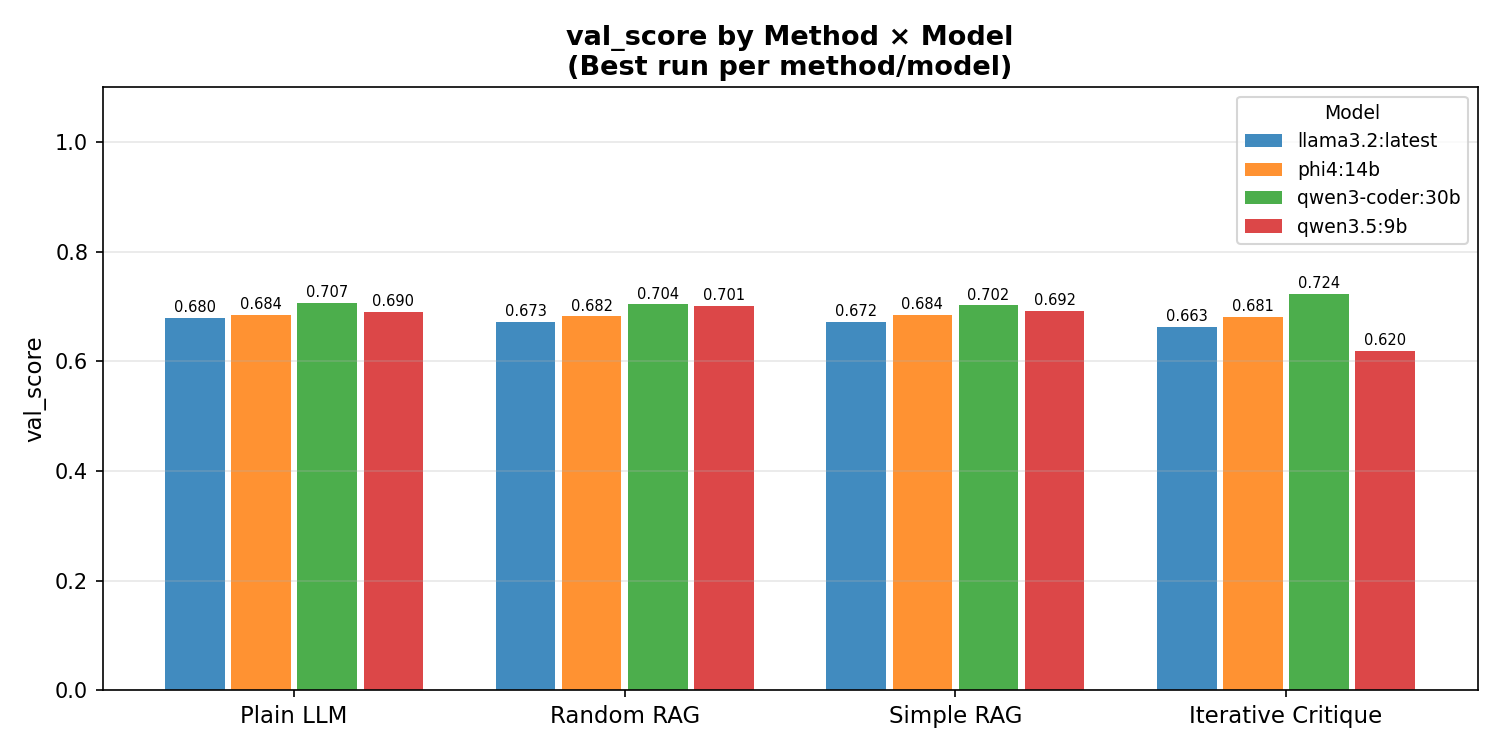

  generalizability_faithfulness_by_model.png → Drive


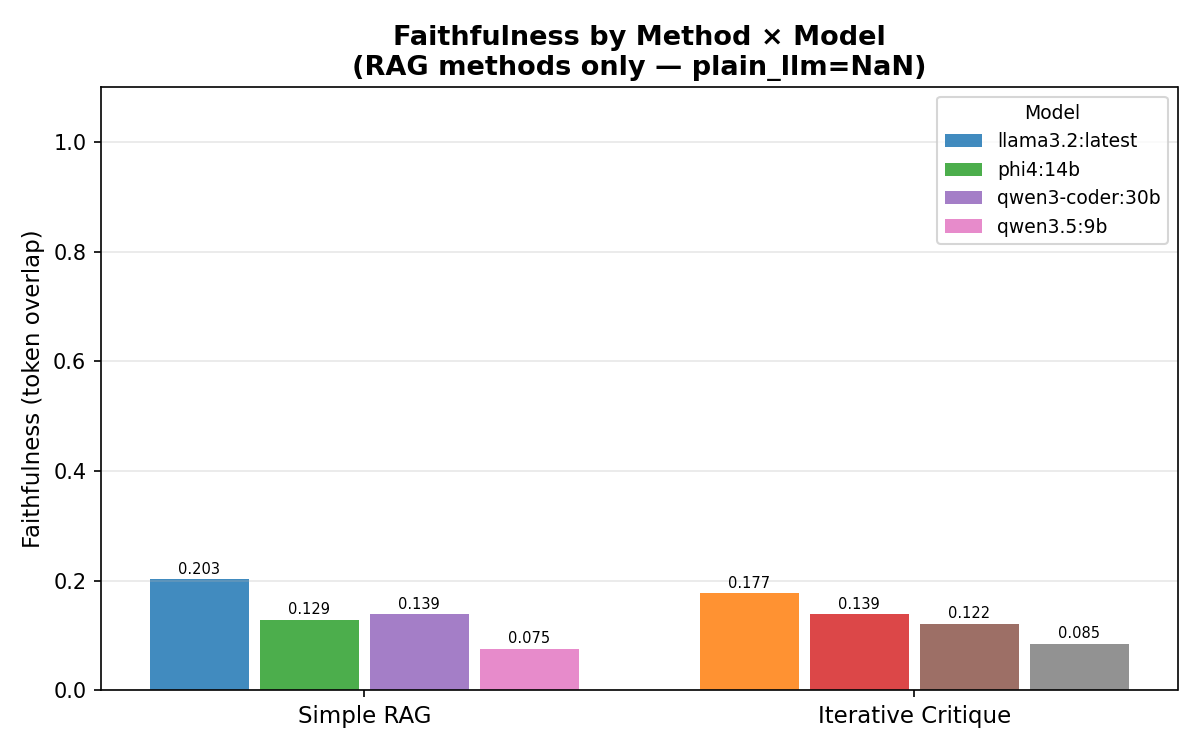

  generalizability_rank_stability.png → Drive


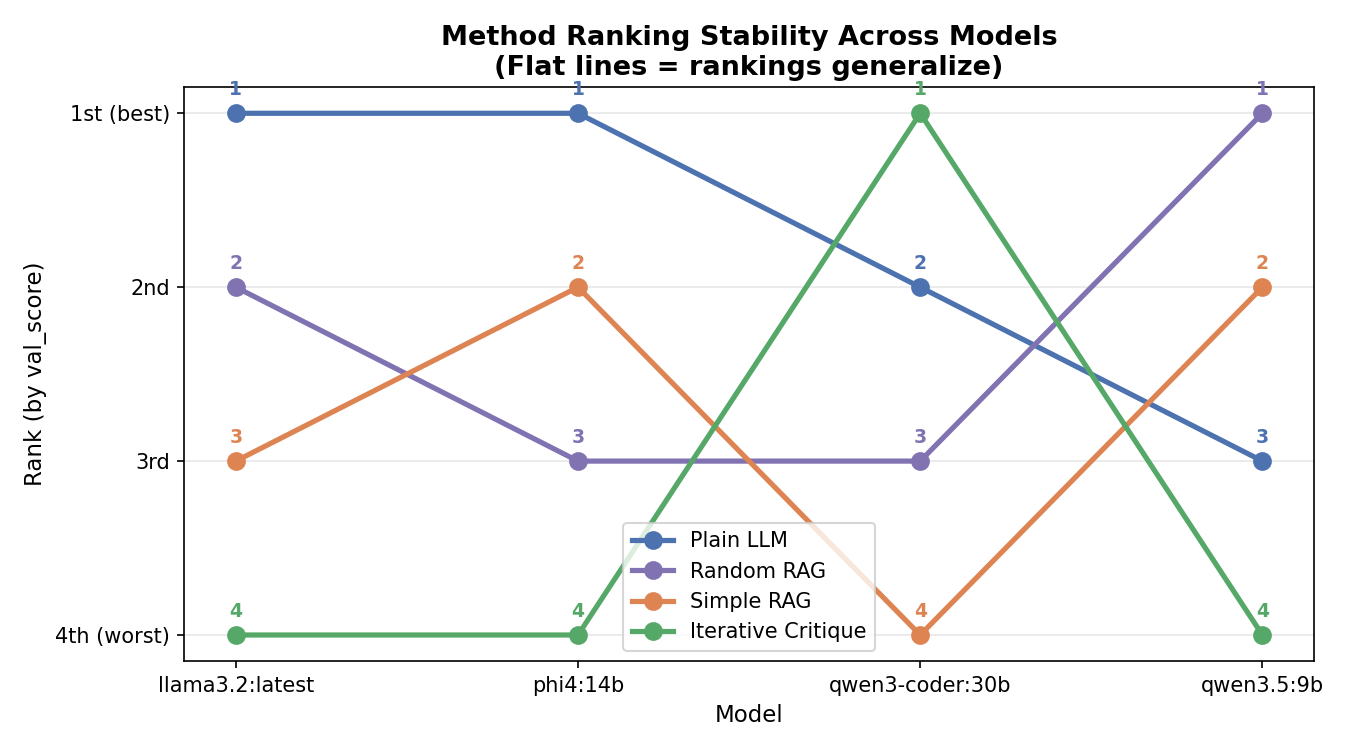

  generalizability_rank_correlation.png → Drive


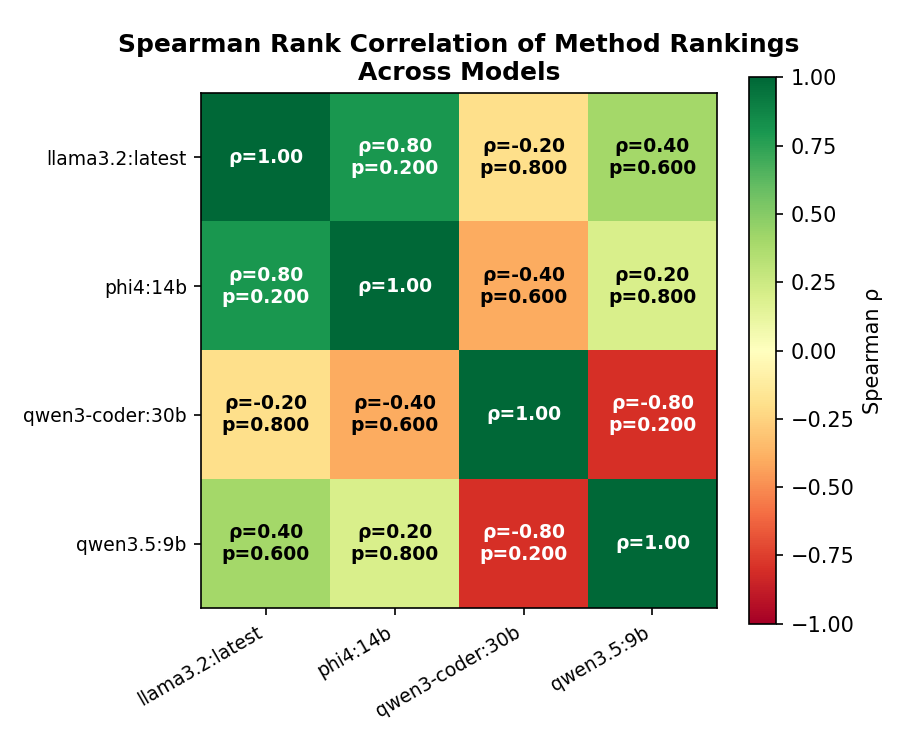

  generalizability_report.txt → Drive


In [ ]:
from IPython.display import Image, display

!python analyze_generalizability.py

generalizability_charts = [
    'val_score_by_model.png',
    'faithfulness_by_model.png',
    'rank_stability.png',
    'rank_correlation.png',
]

for fname in generalizability_charts:
    src = os.path.join('plots_generalizability', fname)
    save_to_both(src, f'generalizability_{fname}', subdir='plots')
    if os.path.exists(src):
        display(Image(src))

save_to_both(
    'plots_generalizability/generalizability_report.txt',
    'generalizability_report.txt'
)

Loaded 61 results from results_unitest.tsv

  sensitivity_weights.png
  statistical_report.txt

  STATISTICAL SIGNIFICANCE REPORT — Unit Test Generation
  Methods: Kruskal-Wallis → Pairwise Mann-Whitney U (Bonferroni)
  Effect sizes: Cohen's d (Cohen 1988)

──────────────────────────────────────────────────────────────────────
  Model: llama3.2:latest  (n=16 runs)
──────────────────────────────────────────────────────────────────────

Primary: val_score
  Kruskal-Wallis: H=3.618, df=3, p=0.3058
  Comparison                                        U    p_raw    p_adj        d  Effect
  ------------------------------------------------------------------------------
  Plain LLM vs Random RAG                     13.0    0.2000    1.0000      1.107  large
  Plain LLM vs Simple RAG                     12.0    0.3429    1.0000      0.843  large
  Plain LLM vs Iterative Critique             13.0    0.2000    1.0000      1.391  large
  Random RAG vs Simple RAG                      4.0    0.3429  

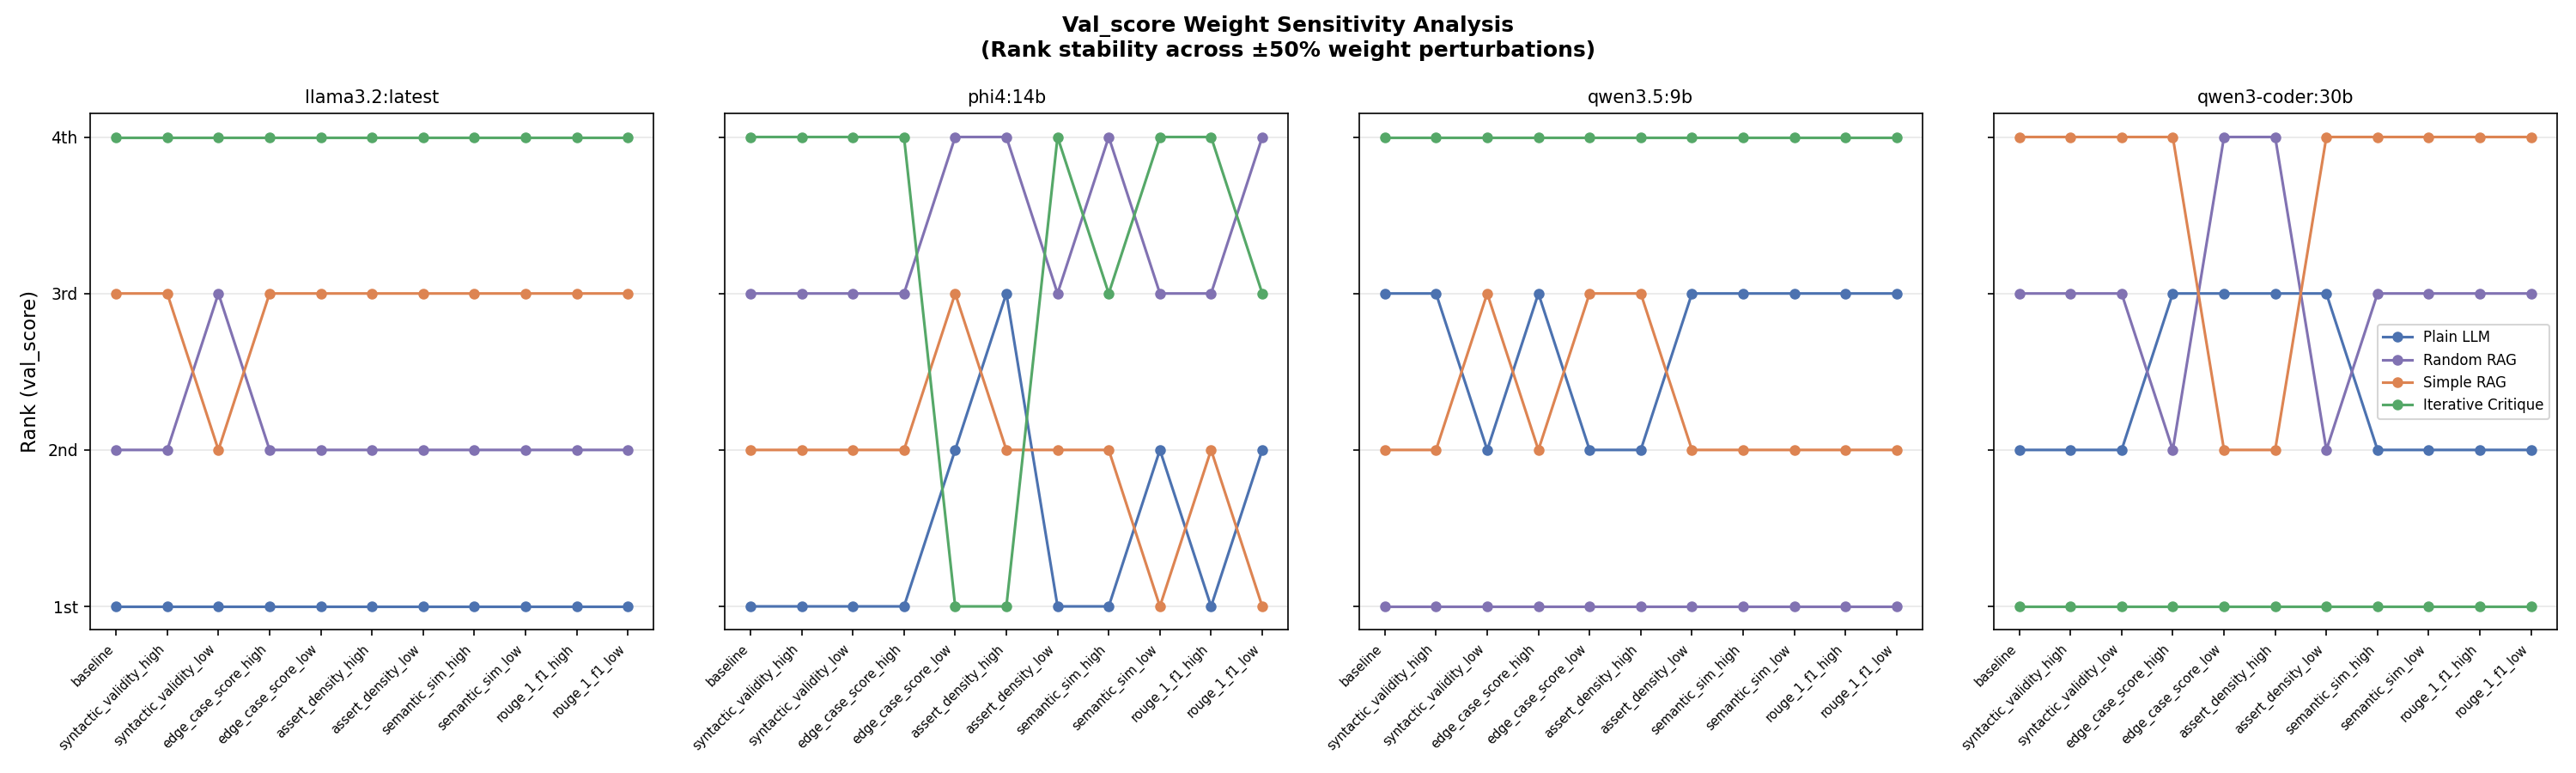

Statistical analysis complete.


In [ ]:
from IPython.display import Image, display

!python statistical_tests.py

save_to_both(
    'plots_generalizability/statistical_report.txt',
    'statistical_report.txt'
)
save_to_both(
    'plots_generalizability/sensitivity_weights.png',
    'sensitivity_weights.png', subdir='plots'
)

if os.path.exists('plots_generalizability/sensitivity_weights.png'):
    display(Image('plots_generalizability/sensitivity_weights.png'))
print('Statistical analysis complete.')

In [ ]:
# DISABLED — this cell edited results_mutation.tsv in place (dropping rows and
# rewriting the file) without regenerating mutation_report.txt. That desynchronised
# the two files: the report still claimed IC x llama3.2 = 0.50 / 6 killed while the
# TSV said 1.00 / 11 killed. The TSV must only ever be written by
# mutation_testing.py, so it stays a pure function of the checkpoints.
#
# To drop a model's results now: delete its checkpoints and re-run the sweep.
# The original code is preserved below for reference only.
#
# import pandas as pd, os, shutil
# os.chdir(REPO_DIR)
# 
# # Restore the GOOD TSV from Drive first (it has the model column)
# drive_tsv = os.path.join(DRIVE_DIR, 'results', 'results_mutation.tsv')
# if not os.path.exists(drive_tsv):
#     print(f'Warning: No TSV at {drive_tsv} — cannot restore from Drive. Using local file if exists.')
#     # If drive_tsv doesn't exist, proceed with local if available, or an empty df.
#     # No raise here, to allow for fresh start scenarios if local is also empty/missing.
# else:
#     shutil.copy(drive_tsv, 'results_mutation.tsv')
#     print(f'Restored from Drive: {drive_tsv}')
# 
# # Check if local results_mutation.tsv exists before reading
# if os.path.exists('results_mutation.tsv'):
#     df = pd.read_csv('results_mutation.tsv', sep='\t')
#     print('Columns after reading TSV:', list(df.columns))
#     print(f'Rows before trim: {len(df)}')
# 
#     if 'model' not in df.columns:
#         print('Error: "model" column not found in results_mutation.tsv. Cannot trim.')
#     else:
#         df = df[~df['model'].isin(['qwen3.5:9b', 'qwen3-coder:30b'])]
#         df.to_csv('results_mutation.tsv', sep='\t', index=False, float_format='%.6f')
#         save_to_both('results_mutation.tsv', 'results_mutation.tsv')
#         print(f'Rows after trim:  {len(df)}')
#         # Ensure these columns exist before printing
#         display_cols = [c for c in ['method','model','reasoning','mean_kill_rate','n_samples_valid'] if c in df.columns]
#         if display_cols:
#             print(df[display_cols].to_string(index=False))
#         else:
#             print('No relevant columns to display after trimming.')
# else:
#     print('results_mutation.tsv not found locally. Skipping DataFrame operations.')
#     df = pd.DataFrame() # Initialize an empty DataFrame if no file is found
# 
# # Clear local qwen checkpoints
# # Ensure .checkpoints_mutation directory exists before listing
# local_checkpoints_dir = '.checkpoints_mutation'
# if os.path.isdir(local_checkpoints_dir):
#     for f in os.listdir(local_checkpoints_dir):
#         if 'qwen' in f.lower():
#             os.remove(os.path.join(local_checkpoints_dir, f))
#             print(f'  removed local: {f}')
# else:
#     print(f'Local checkpoints directory {local_checkpoints_dir} not found.')
# 
# # Clear Drive qwen checkpoints
# drive_ckpt = os.path.join(DRIVE_DIR, 'checkpoints_mutation')
# if os.path.isdir(drive_ckpt):
#     for f in os.listdir(drive_ckpt):
#         if 'qwen' in f.lower():
#             os.remove(os.path.join(drive_ckpt, f))
#             print(f'  removed drive: {f}')
# else:
#     print(f'Drive checkpoints directory {drive_ckpt} not found.')


Restored from Drive: /content/drive/MyDrive/PhD_autoresearch/results/results_mutation.tsv
Columns after reading TSV: ['method', 'reasoning', 'model', 'mean_kill_rate', 'std_kill_rate', 'median_kill_rate', 'total_mutants', 'total_killed', 'total_survived', 'total_equivalent', 'n_samples_valid', 'kill_arithmetic', 'kill_boundary', 'kill_comparison', 'kill_negate_bool', 'kill_return_none']
Rows before trim: 9
  results_mutation.tsv → Drive
Rows after trim:  8
            method           model reasoning  mean_kill_rate  n_samples_valid
         Plain LLM llama3.2:latest      base        0.721926               29
        Random RAG llama3.2:latest      base        0.652683               22
        Simple RAG llama3.2:latest      base        0.674044               20
Iterative Critique llama3.2:latest      base        0.500000                4
         Plain LLM        phi4:14b      base        0.859632               30
        Random RAG        phi4:14b      base        0.872463           

In [ ]:
import subprocess
r = subprocess.run(
    ['python', 'mutation_testing.py',
      '--regenerate', '--max-samples', '30', '--model', 'qwen3.5:9b'],
    capture_output=True, text=True, cwd=REPO_DIR
)
print('--- STDOUT (last 3000 chars) ---')
print(r.stdout[-3000:])
print('--- STDERR (last 3000 chars) ---')
print(r.stderr[-3000:])
print('--- exit code:', r.returncode)

--- STDOUT (last 3000 chars) ---
Loaded dataset: 100 samples
  Using model: qwen3.5:9b

  plain_llm_base_qwen3.5_9b: loaded 30 samples from cache

  random_rag_base_qwen3.5_9b: loaded 30 samples from cache

  simple_rag_base_qwen3.5_9b: loaded 30 samples from cache

  iterative_critique_base_qwen3.5_9b: loaded 30 samples from cache

Running mutation analysis...

  Analyzing: plain_llm_base_qwen3.5_9b (30 samples)...

--- STDERR (last 3000 chars) ---
7.51it/s, Materializing param=encoder.layer.5.attention.self.value.weight]
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2915.36it/s, Materializing param=pooler.dense.weight]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Traceback (most recent call last):
  File "/

Restored results_mutation.tsv from Drive
Restored 16 mutation checkpoint files from Drive
Restored 5 mutation-analysis checkpoint files from Drive

SKIP llama3.2:latest — 4 method rows already in results_mutation.tsv

SKIP phi4:14b — 4 method rows already in results_mutation.tsv

SKIP qwen3.5:9b — 4 method rows already in results_mutation.tsv

  MUTATION RUN — model = qwen3-coder:30b
  [sync] 21 checkpoint files → Drive
  [sync] 21 checkpoint files → Drive
  [sync] 21 checkpoint files → Drive
  [sync] 21 checkpoint files → Drive
  [sync] 21 checkpoint files → Drive
  [sync] 21 checkpoint files → Drive
  [sync] 21 checkpoint files → Drive
  [sync] 21 checkpoint files → Drive
  [sync] 21 checkpoint files → Drive
  [sync] 21 checkpoint files → Drive
  [sync] 21 checkpoint files → Drive
  [sync] 21 checkpoint files → Drive
  [sync] 21 checkpoint files → Drive
  [sync] 21 checkpoint files → Drive
  [sync] 21 checkpoint files → Drive
  [sync] 21 checkpoint files → Drive
  [sync] 21 checkpoin

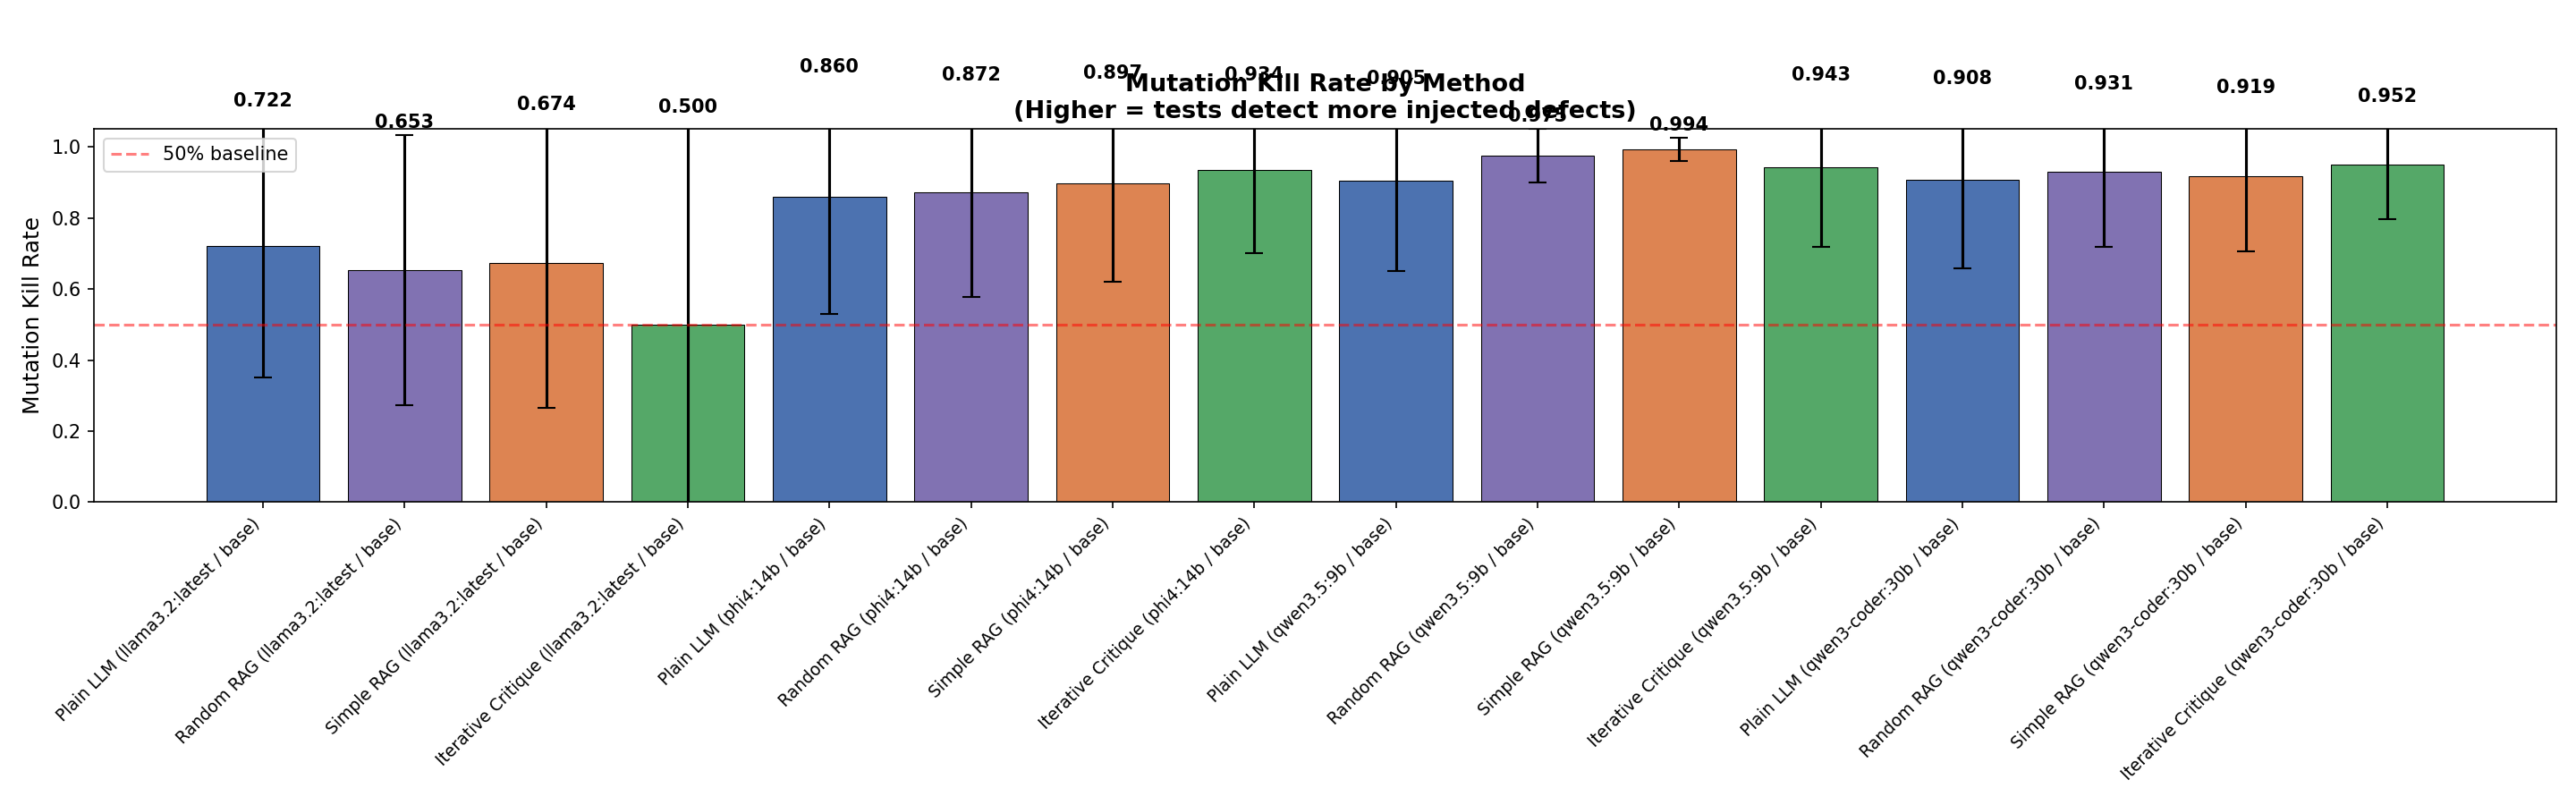

  mutation_kill_rate_by_operator.png → Drive


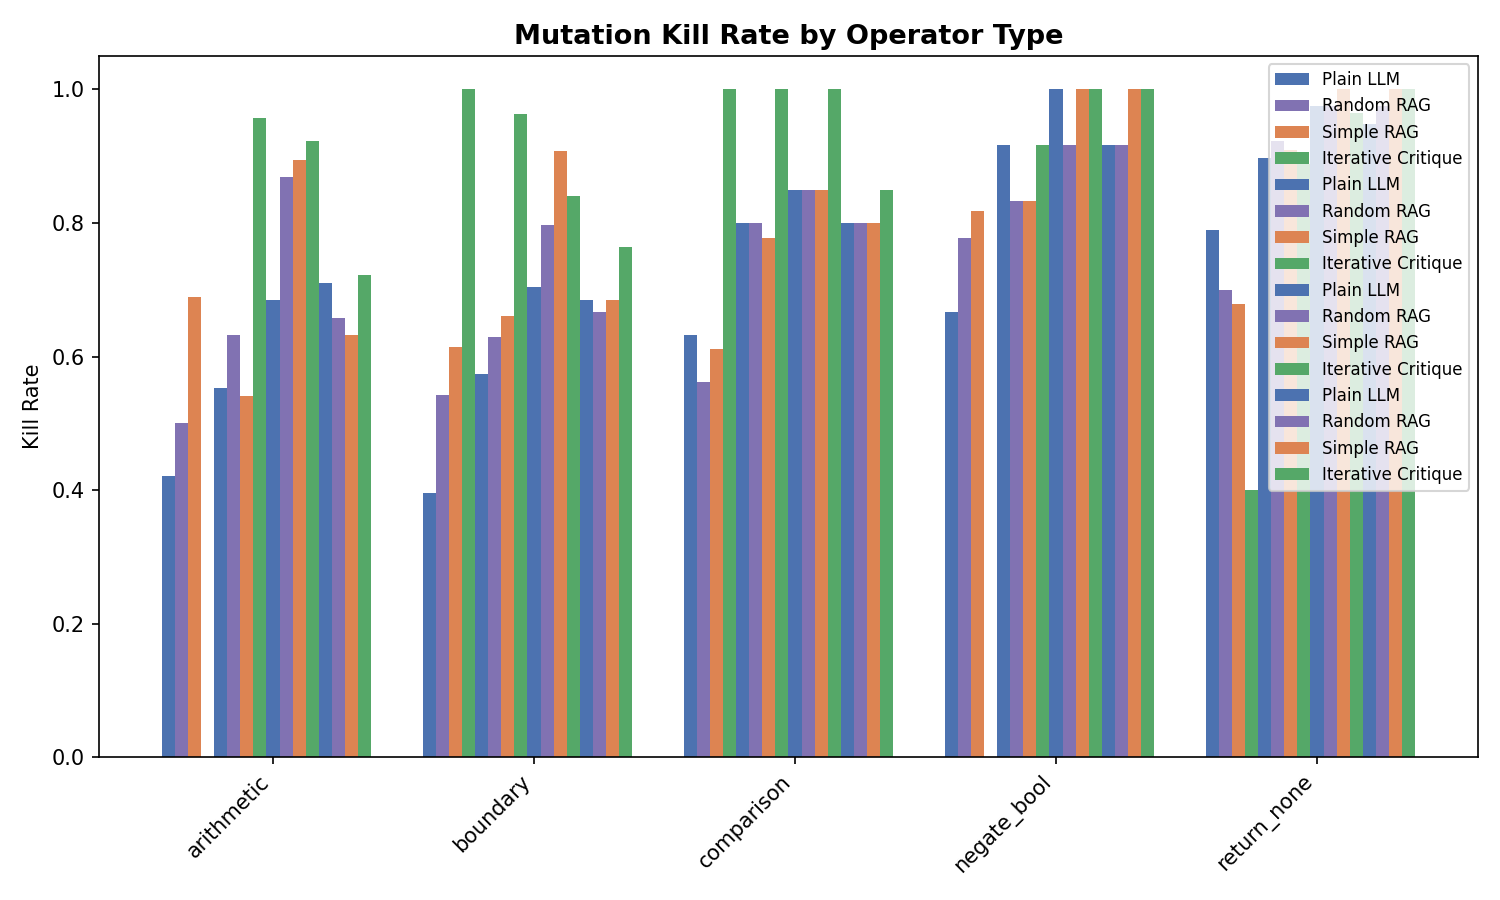

  mutation_report.txt → Drive

  MUTATION KILL RATE SUMMARY (all models)
            method           model reasoning  mean_kill_rate  std_kill_rate  n_samples_valid  total_killed  total_mutants
Iterative Critique llama3.2:latest      base        0.500000       0.577350                4             6             11
Iterative Critique        phi4:14b      base        0.934211       0.233365               19            93             99
Iterative Critique qwen3-coder:30b      base        0.951618       0.155041               29           131            156
Iterative Critique      qwen3.5:9b      base        0.942857       0.224206               20            82             88
         Plain LLM llama3.2:latest      base        0.721926       0.372199               29            87            160
         Plain LLM        phi4:14b      base        0.859632       0.330164               30           114            163
         Plain LLM qwen3-coder:30b      base        0.907776       0.2502

In [ ]:
import os, shutil, subprocess, threading
import pandas as pd
from IPython.display import Image, display

# ---- Knobs ----
# 100 = the full prepared corpus. The existing checkpoints hold the first 30, and
# mutation_testing.py resumes per cell, so this generates only the remaining 70.
# Do NOT change NUM_EVAL_SAMPLES in prepare_unitest.py: a different value makes
# rng.choice draw a different corpus, and the existing checkpoints become unusable.
MUTATION_SAMPLES = 100
RUN_DECONTAM_ARM = True               # also sweep the decontaminated corpus
MUTATION_FRESH   = False              # ← False to resume; True to wipe and start over
MUTATION_MODELS  = MODELS
SYNC_INTERVAL_SECS = 300              # Drive sync every 5 min while a model is running

os.chdir(REPO_DIR)
DRIVE_CKPT = os.path.join(DRIVE_DIR, 'checkpoints_mutation')
DRIVE_ANALYSIS_CKPT = os.path.join(DRIVE_DIR, 'checkpoints_mutation_analysis')

# ---- Optional fresh start ----
if MUTATION_FRESH:
    for path in ['.checkpoints_mutation', '.checkpoints_mutation_analysis', 'plots_mutation', 'results_mutation.tsv']:
        if os.path.isdir(path):
            shutil.rmtree(path, ignore_errors=True)
        elif os.path.isfile(path):
            os.remove(path)
    print('FRESH: cleared local mutation checkpoints, plots, TSV')
else:
    # Restore prior progress from Drive
    drive_tsv = os.path.join(DRIVE_DIR, 'results', 'results_mutation.tsv')
    if os.path.exists(drive_tsv):
        shutil.copy(drive_tsv, 'results_mutation.tsv')
        print('Restored results_mutation.tsv from Drive')
    if os.path.isdir(DRIVE_CKPT):
        os.makedirs('.checkpoints_mutation', exist_ok=True)
        n = 0
        for f in os.listdir(DRIVE_CKPT):
            shutil.copy(os.path.join(DRIVE_CKPT, f),
                        os.path.join('.checkpoints_mutation', f))
            n += 1
        print(f'Restored {n} mutation checkpoint files from Drive')
    if os.path.isdir(DRIVE_ANALYSIS_CKPT):
        os.makedirs('.checkpoints_mutation_analysis', exist_ok=True)
        n = 0
        for f in os.listdir(DRIVE_ANALYSIS_CKPT):
            shutil.copy(os.path.join(DRIVE_ANALYSIS_CKPT, f),
                        os.path.join('.checkpoints_mutation_analysis', f))
            n += 1
        print(f'Restored {n} mutation-analysis checkpoint files from Drive')

# ---- Align the corpus to the existing checkpoints (REQUIRED) ----
# prepare_unitest.py emits [combined[i] for i in sorted(indices)], but the
# checkpoints were generated against an unsorted permutation of the same 100
# functions. Resuming keys on sample COUNT, so without this step samples 0-29
# would come from one ordering and 30-99 from another, and a single sample_idx
# would denote different functions in different cells — silently corrupting every
# paired test. align_corpus.py reorders the cache to match, and
# mutation_testing.py then verifies task ids position by position before resuming.
print(f'\n{"="*70}\n  ALIGNING CORPUS TO EXISTING CHECKPOINTS\n{"="*70}')
rc_align = subprocess.run(['python', 'align_corpus.py'], check=False).returncode
if rc_align != 0:
    raise RuntimeError(
        'align_corpus.py failed. Do NOT continue — the sweep would either abort '
        'on the corpus guard or, worse, mix two orderings. Resolve first.')
save_to_both('corpus_manifest.tsv', 'corpus_manifest.tsv')

# ---- Skip models already complete in the TSV ----
def model_done(model_name):
    if not os.path.exists('results_mutation.tsv'):
        return False
    try:
        df = pd.read_csv('results_mutation.tsv', sep='\t')
    except Exception:
        return False
    if 'model' not in df.columns:
        return False
    return len(df[df['model'] == model_name]) >= 4   # 4 methods finished

# ---- Background syncer: copy local mutation checkpoints to Drive every N seconds ----
def _sync_checkpoints_once():
    n = 0
    for local_dir, drive_dir in [('.checkpoints_mutation', DRIVE_CKPT),
                                  ('.checkpoints_mutation_analysis', DRIVE_ANALYSIS_CKPT)]:
        if not os.path.isdir(local_dir):
            continue
        os.makedirs(drive_dir, exist_ok=True)
        for f in os.listdir(local_dir):
            try:
                shutil.copy(os.path.join(local_dir, f),
                            os.path.join(drive_dir, f))
                n += 1
            except Exception:
                pass
    return n

def _sync_loop(stop_event):
    while not stop_event.is_set():
        if stop_event.wait(SYNC_INTERVAL_SECS):
            break
        n = _sync_checkpoints_once()
        if n:
            print(f'  [sync] {n} checkpoint files → Drive')

# ---- Run mutation testing per model ----
for m in MUTATION_MODELS:
    if model_done(m):
        print(f'\nSKIP {m} — 4 method rows already in results_mutation.tsv')
        continue

    print(f'\n{"="*70}\n  MUTATION RUN — model = {m}\n{"="*70}')

    stop_event = threading.Event()
    syncer = threading.Thread(target=_sync_loop, args=(stop_event,), daemon=True)
    syncer.start()

    try:
        rc = subprocess.run(
            ['python', 'mutation_testing.py',
             '--regenerate',
             '--max-samples', str(MUTATION_SAMPLES),
             '--regen-checkpoints-dir', '.checkpoints_mutation',
             '--manifest', 'corpus_manifest.tsv',
             '--model', m],
            check=False,
        ).returncode
    finally:
        stop_event.set()
        syncer.join(timeout=10)

    if rc != 0:
        print(f'  WARNING: mutation_testing.py exited with code {rc} for {m}')

    # Final post-model sync (TSV + checkpoints)
    save_to_both('results_mutation.tsv', 'results_mutation.tsv')
    n = _sync_checkpoints_once()
    print(f'  Synced {n} checkpoint files to Drive after {m}')

# ---- Save final artifacts to Drive ----
for fname in ['kill_rate_by_method.png', 'kill_rate_by_operator.png']:
    src = os.path.join('plots_mutation', fname)
    save_to_both(src, f'mutation_{fname}', subdir='plots')
    if os.path.exists(src):
        display(Image(src))

save_to_both('plots_mutation/mutation_report.txt', 'mutation_report.txt')

# ---- Summary ----
if os.path.exists('results_mutation.tsv'):
    mdf = pd.read_csv('results_mutation.tsv', sep='\t')
    cols = [c for c in ['method', 'model', 'reasoning', 'mean_kill_rate',
                        'std_kill_rate', 'n_samples_valid',
                        'total_killed', 'total_mutants'] if c in mdf.columns]
    sort_cols = [c for c in ['method', 'model'] if c in mdf.columns]
    print('\n' + '='*70)
    print('  MUTATION KILL RATE SUMMARY (all models)')
    print('='*70)
    print(mdf[cols].sort_values(sort_cols).to_string(index=False))

    if 'model' in mdf.columns:
        print('\nPer-model mean kill rate:')
        print(mdf.groupby('model')['mean_kill_rate'].mean().round(4).to_string())
        print('\nPer-method mean kill rate (across models):')
        print(mdf.groupby('method')['mean_kill_rate'].mean().round(4).to_string())
else:
    print('No results_mutation.tsv produced.')

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
#  DECONTAMINATION ARM
#  HumanEval and MBPP are both 2021 and ship their reference solutions and
#  canonical suites; llama3.2's cutoff is December 2023. This arm rebuilds the
#  corpus with the function and its parameters renamed (AST, deterministic,
#  semantics-preserving, sanity-checked against the rewritten reference tests)
#  and re-runs the sweep. The kill-rate delta is the contamination evidence the
#  submitted manuscript never provided.
# ════════════════════════════════════════════════════════════════════════════
if RUN_DECONTAM_ARM:
    import os, subprocess
    os.chdir(REPO_DIR)

    DECON_CKPT = '.checkpoints_mutation_decontam'
    DECON_DATA = os.path.expanduser(
        '/content/.cache/autoresearch_unitest/eval_dataset_v3_decontaminated.pkl')

    print(f'\n{"="*70}\n  BUILDING DECONTAMINATED CORPUS\n{"="*70}')
    rc = subprocess.run(['python', 'decontaminate.py'], check=False).returncode
    if rc != 0:
        raise RuntimeError('decontaminate.py failed — not running the arm.')
    save_to_both('corpus_manifest_decontaminated.tsv',
                 'corpus_manifest_decontaminated.tsv')

    for m in MUTATION_MODELS:
        print(f'\n{"="*70}\n  DECONTAM RUN — model = {m}\n{"="*70}')
        rc = subprocess.run(
            ['python', 'mutation_testing.py',
             '--regenerate',
             '--dataset', DECON_DATA,
             '--regen-checkpoints-dir', DECON_CKPT,
             '--manifest', 'corpus_manifest_decontaminated.tsv',
             '--max-samples', str(MUTATION_SAMPLES),
             '--model', m],
            check=False).returncode
        if rc != 0:
            print(f'  WARNING: decontam run exited {rc} for {m}')

    # Sync this arm's checkpoints to their own Drive folder.
    drive_decon = os.path.join(DRIVE_DIR, 'checkpoints_mutation_decontam')
    os.makedirs(drive_decon, exist_ok=True)
    if os.path.isdir(DECON_CKPT):
        import shutil as _sh
        n = 0
        for f in os.listdir(DECON_CKPT):
            _sh.copy(os.path.join(DECON_CKPT, f), os.path.join(drive_decon, f))
            n += 1
        print(f'  synced {n} decontaminated checkpoints to Drive')
else:
    print('RUN_DECONTAM_ARM is False — skipping the decontamination arm.')


Loaded 61 results → generating charts in plots_unitest/
  heatmap.png
  grouped_bar.png
  radar.png
  per_metric_bar.png
  noise_rate.png
  cost_breakdown.png
  faithfulness.png
  interaction.png
  source_split.png
  exec_pass_rate.png

  --- Cross-model charts ---
  model_val_score.png
  model_faithfulness.png
  model_rank_stability.png

Done. Open plots_unitest/ to view charts.
  heatmap.png → Drive


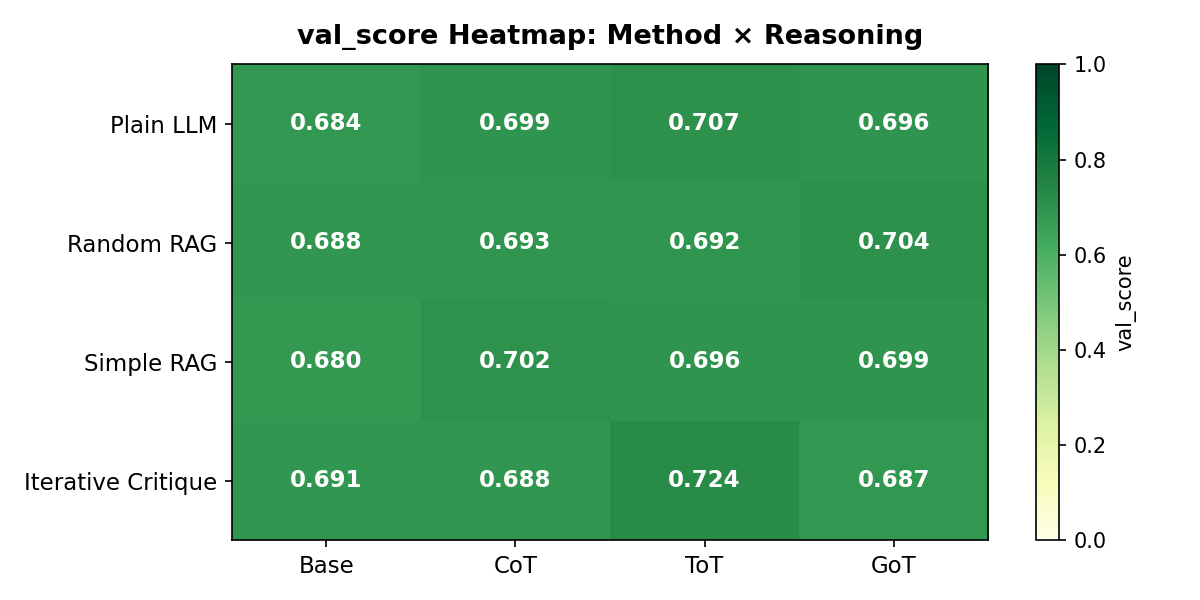

  grouped_bar.png → Drive


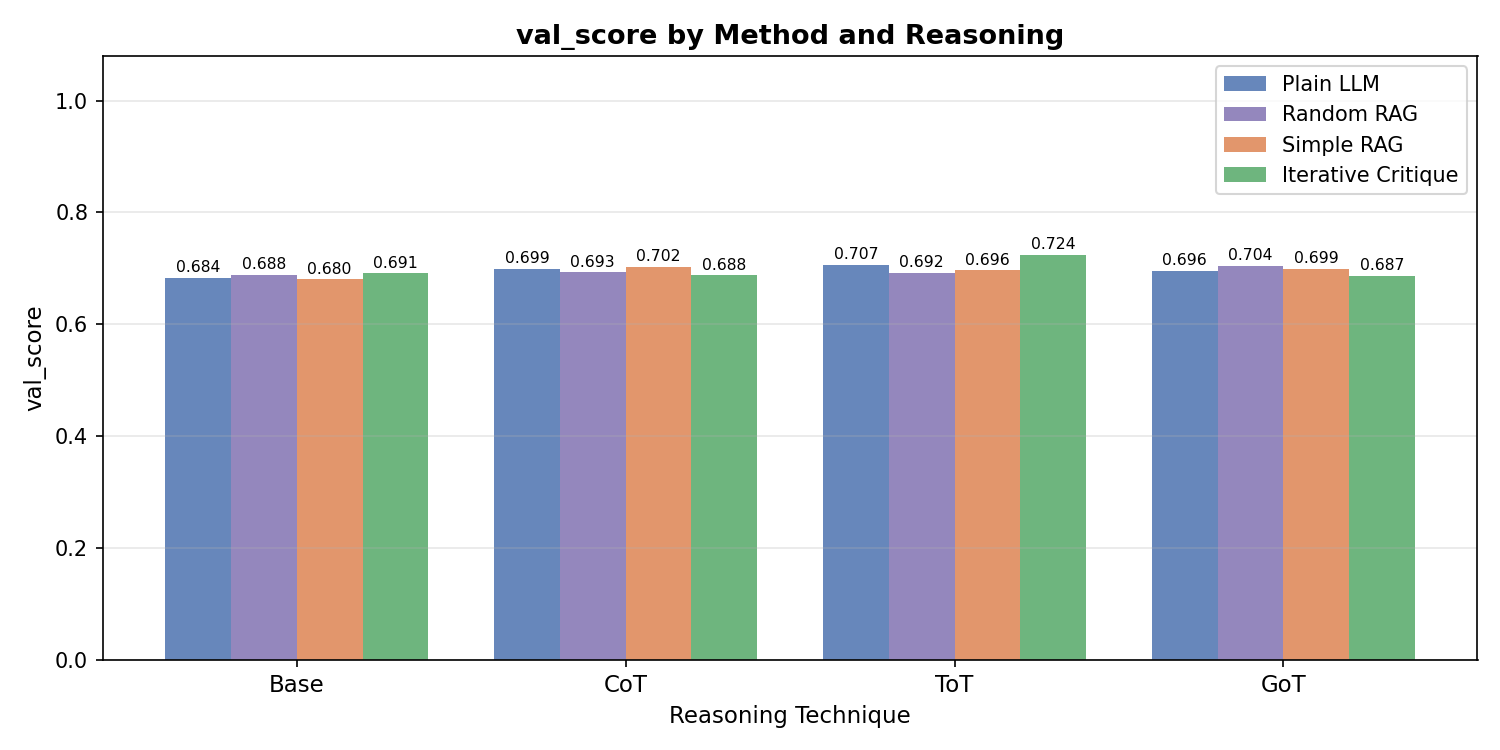

  radar.png → Drive


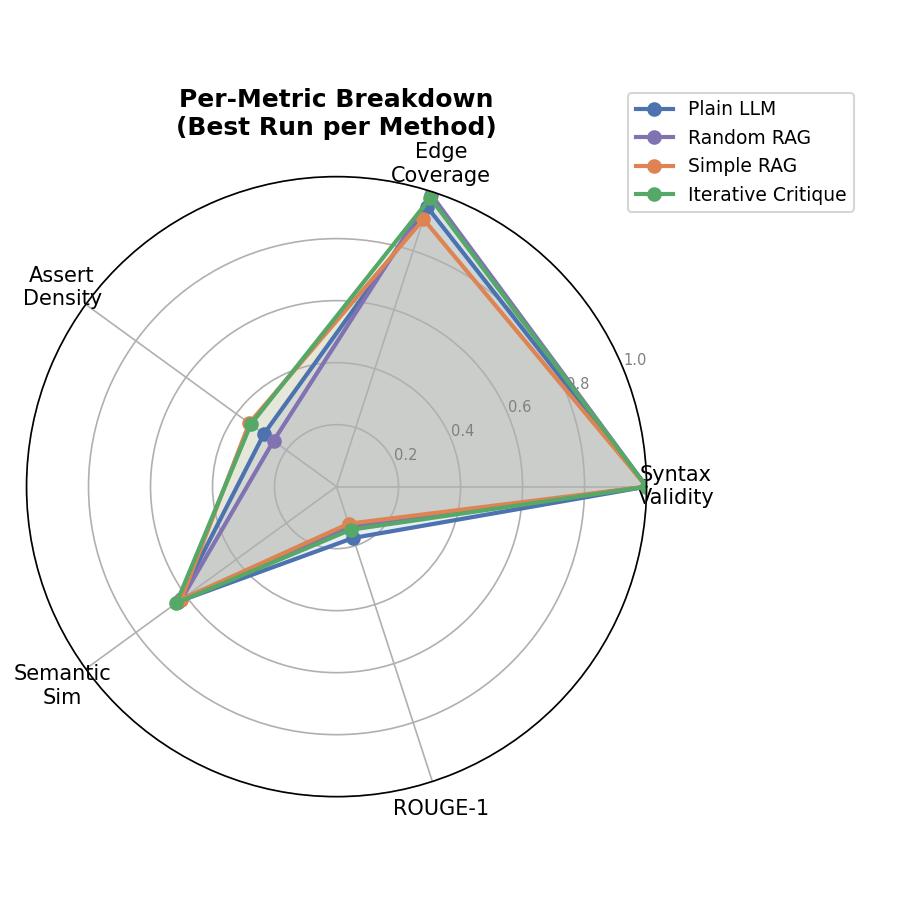

  per_metric_bar.png → Drive


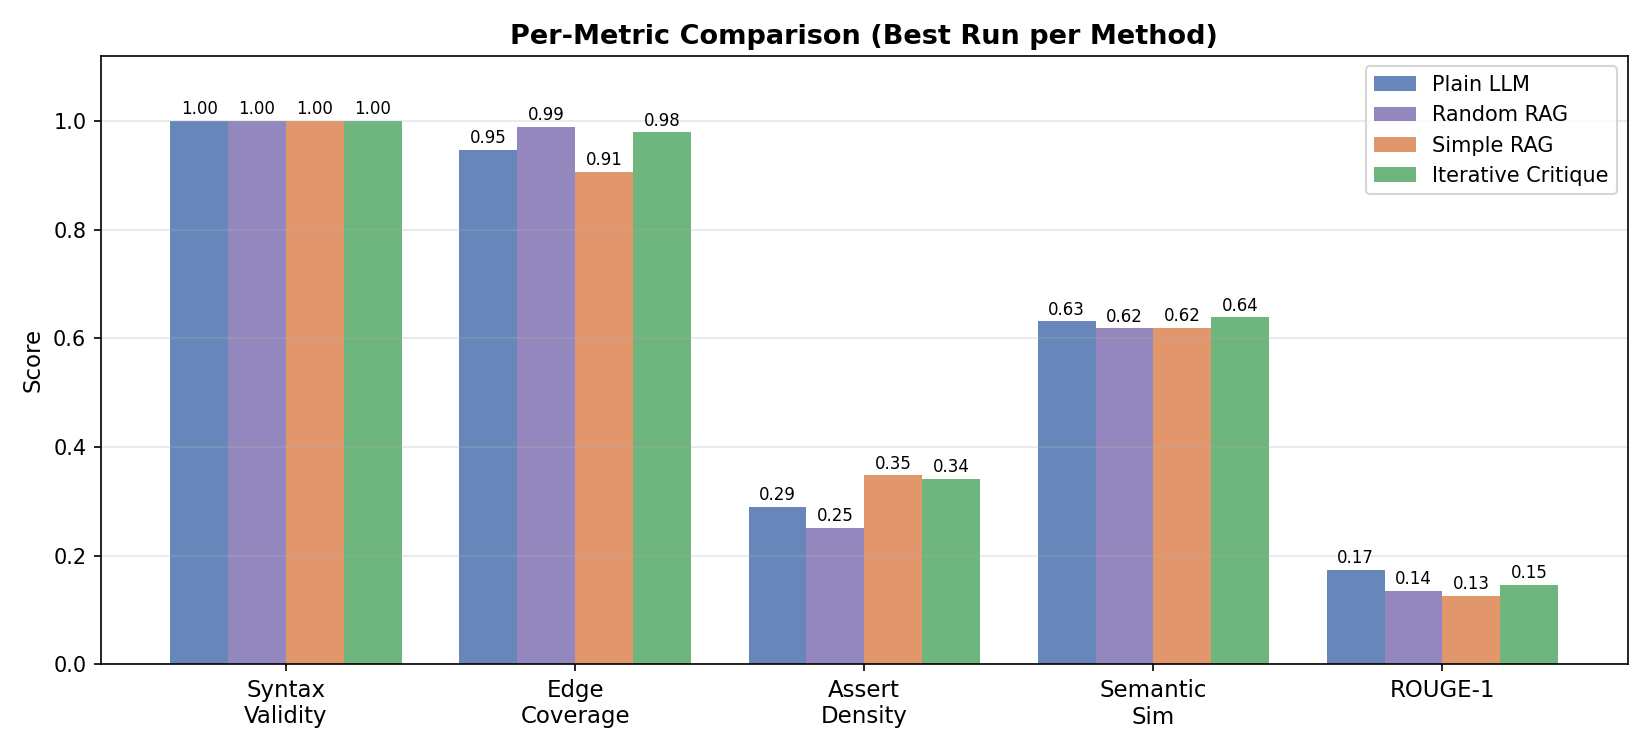

  noise_rate.png → Drive


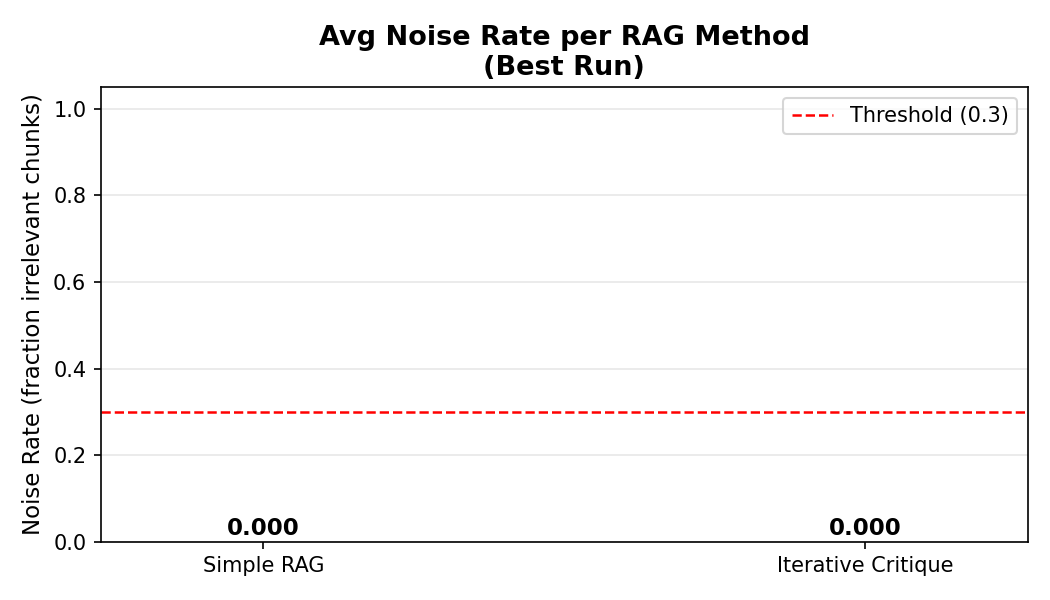

  cost_breakdown.png → Drive


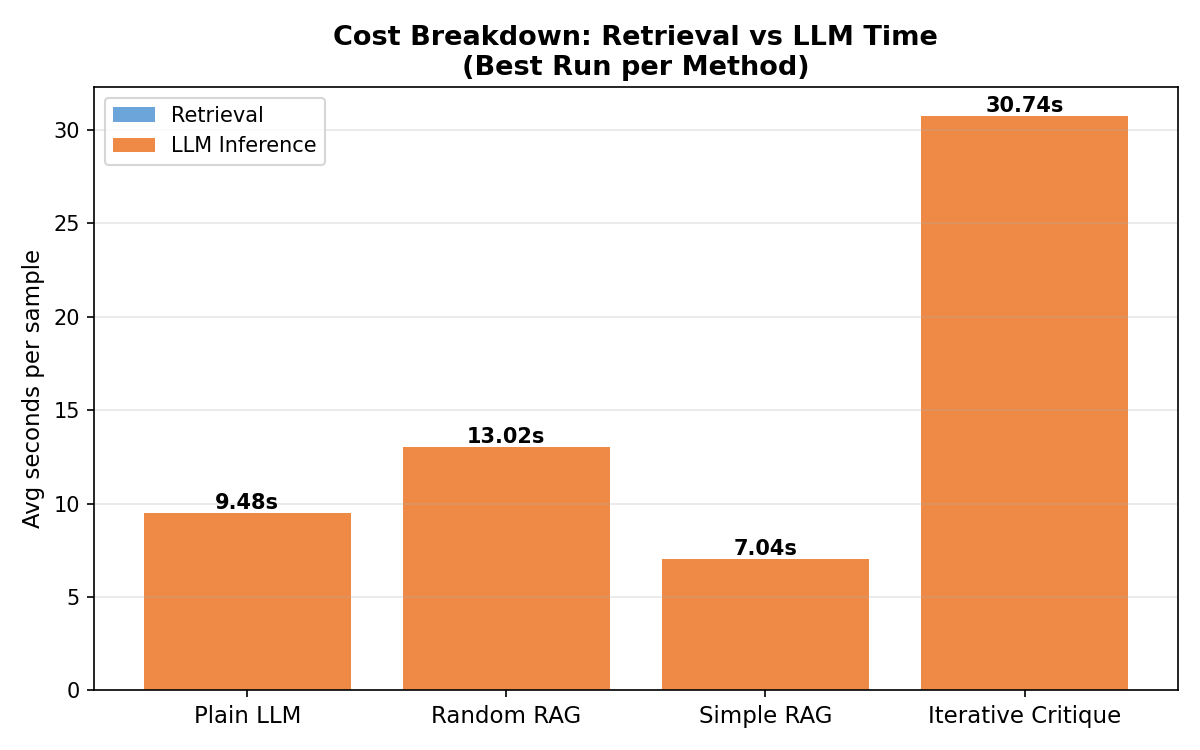

  faithfulness.png → Drive


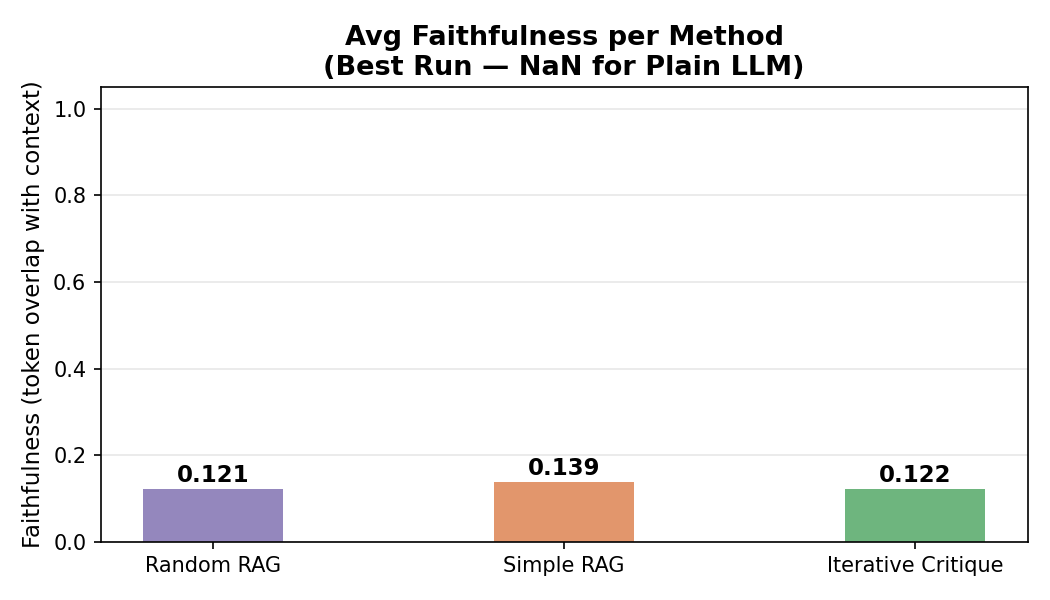

  model_val_score.png → Drive


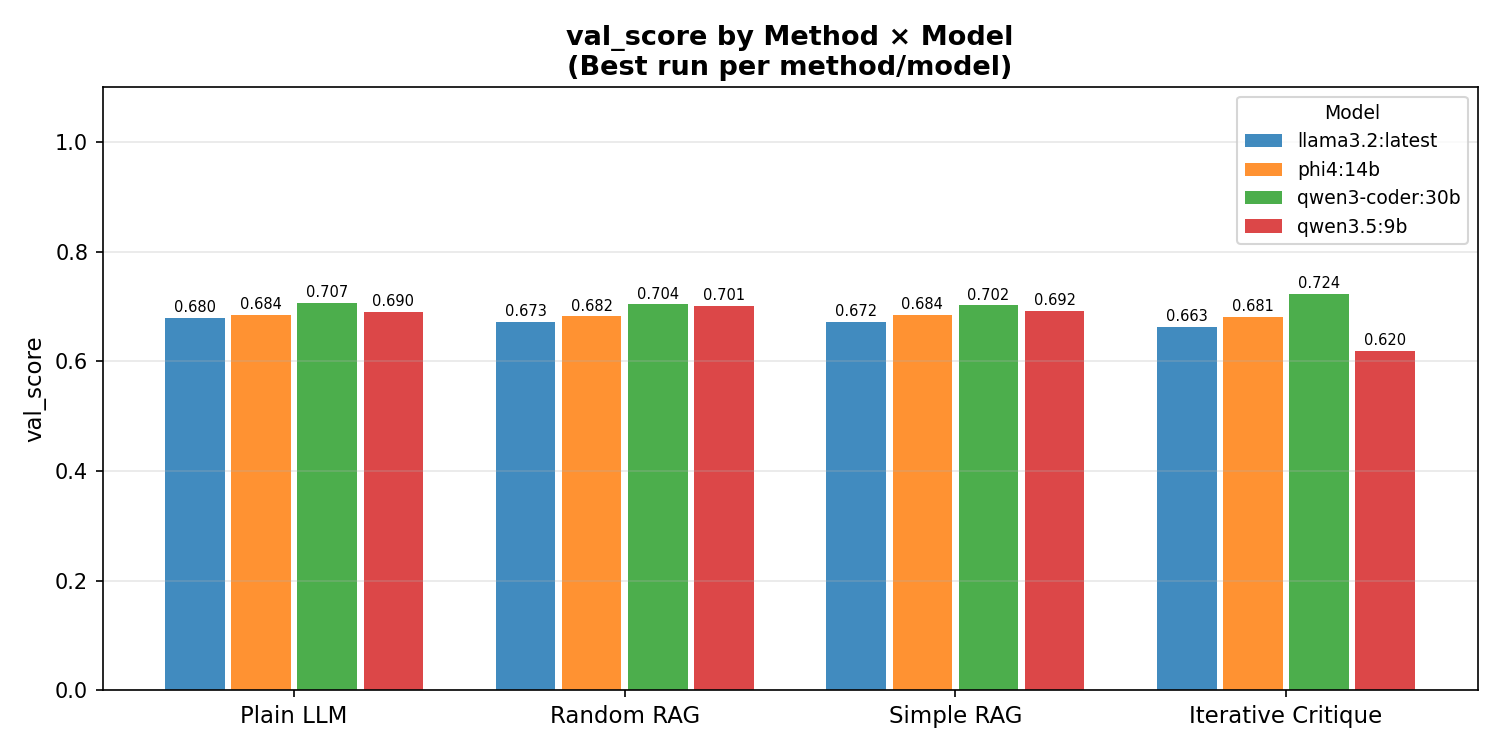

  model_faithfulness.png → Drive


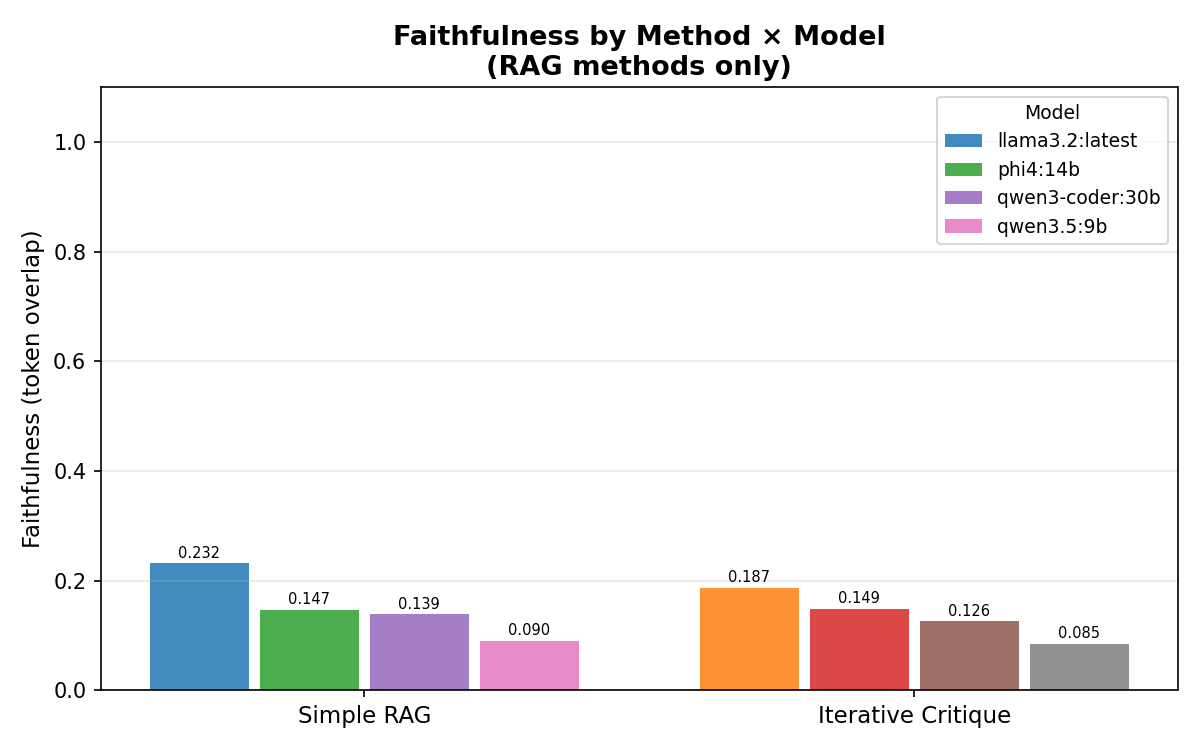

  model_rank_stability.png → Drive


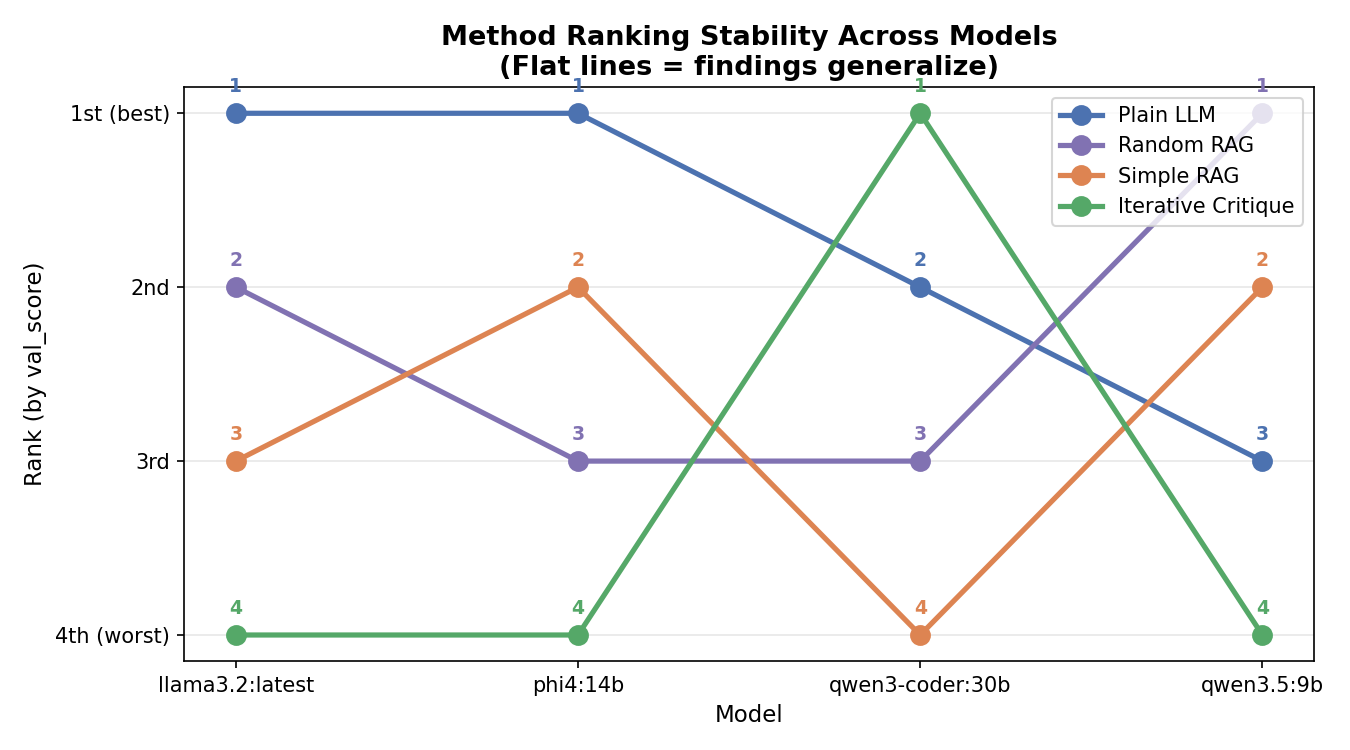

In [ ]:
from IPython.display import Image, display

!python visualize_unitest.py

charts = [
    'heatmap.png', 'grouped_bar.png', 'radar.png', 'per_metric_bar.png',
    'noise_rate.png', 'cost_breakdown.png', 'faithfulness.png',
    'model_val_score.png', 'model_faithfulness.png', 'model_rank_stability.png',
]

for fname in charts:
    src = os.path.join('plots_unitest', fname)
    save_to_both(src, fname, subdir='plots')
    if os.path.exists(src):
        display(Image(src))


In [ ]:
# Load results_docstring.tsv from Drive
docstring_tsv_drive = os.path.join(RESULTS_DIR, 'results_unitest.tsv')
if os.path.exists(docstring_tsv_drive):
    shutil.copy(docstring_tsv_drive, 'results_unitest.tsv')
    print('results_docstring.tsv loaded from Drive.')
else:
    print(f'Not found: {docstring_tsv_drive}')
    print('Run extract_docstring_results.py locally, upload to Drive, then re-run this cell.')

results_docstring.tsv loaded from Drive.


Loading task results:
  'Test Oracle' — 61 rows loaded from results_unitest.tsv
  'Docstring' — results_docstring.tsv not found, skipping.

Generating charts in plots_compare/
  faithfulness_by_task.png
  noise_vs_faithfulness.png
  pareto.png
  summary_table.tsv

       task              method  val_score  faithfulness  noise_rate  total_secs  rouge
Test Oracle           Plain LLM     0.7069           NaN         NaN       9.484 0.1740
Test Oracle         Random\nRAG     0.7039        0.1211         NaN      13.024 0.1351
Test Oracle          Simple RAG     0.7020        0.1387         NaN       7.036 0.1257
Test Oracle Iterative\nCritique     0.7236        0.1216         NaN      30.742 0.1462

Done. Open plots_compare/ to view charts.
  compare_faithfulness_by_task.png → Drive


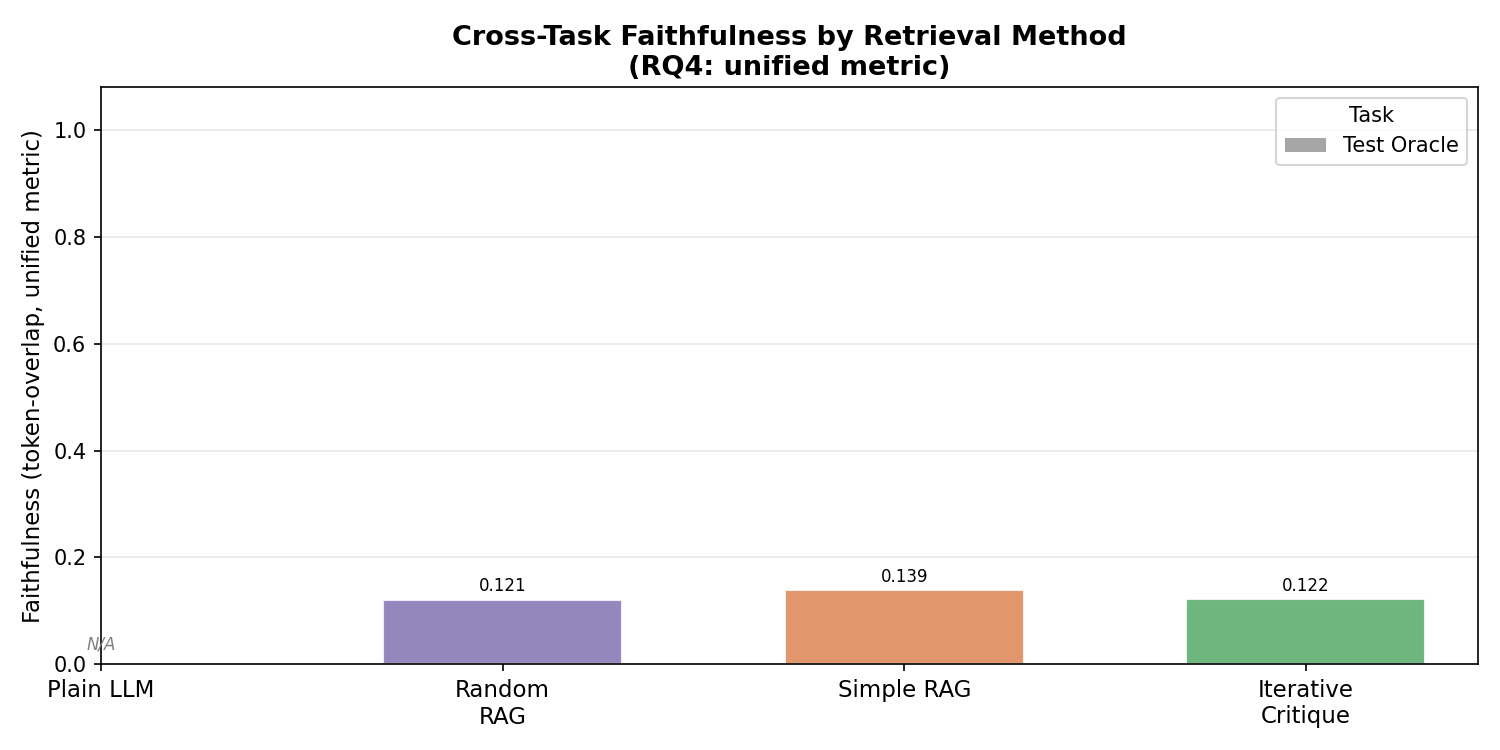

  compare_noise_vs_faithfulness.png → Drive


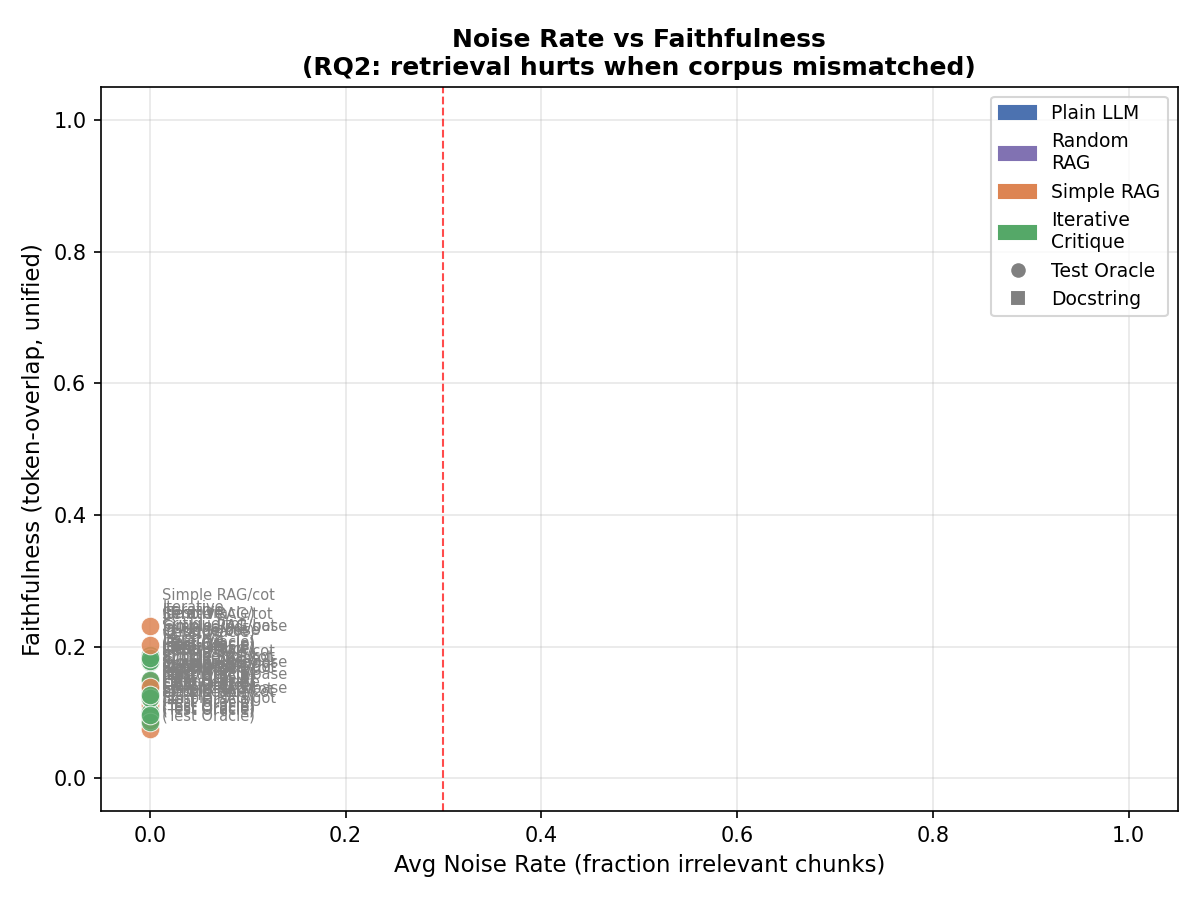

  compare_pareto.png → Drive


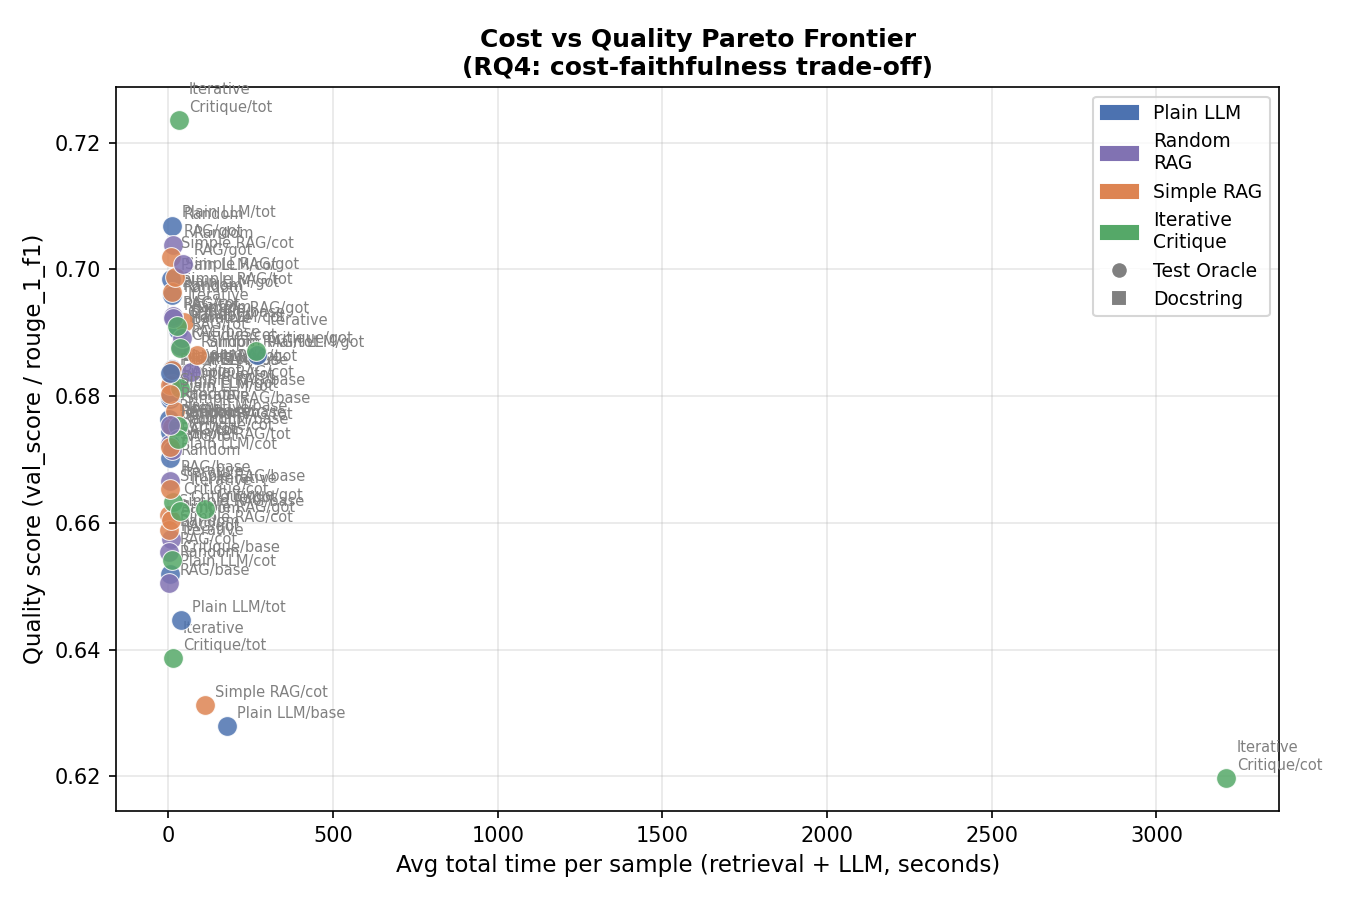

  cross_task_summary.tsv → Drive


In [ ]:
from IPython.display import Image, display

!python compare_tasks.py

compare_charts = ['faithfulness_by_task.png', 'noise_vs_faithfulness.png', 'pareto.png']
for fname in compare_charts:
    src = os.path.join('plots_compare', fname)
    save_to_both(src, f'compare_{fname}', subdir='plots')
    if os.path.exists(src):
        display(Image(src))

save_to_both('plots_compare/summary_table.tsv', 'cross_task_summary.tsv')

In [ ]:
from google.colab import userdata
# Token is read from Colab Secrets (key icon in the left sidebar).
# Never paste a PAT into a notebook cell: it is committed with the file
# and GitHub push protection will block the push.
# ---- Set your GitHub credentials ----
GITHUB_TOKEN = userdata.get("GITHUB_TOKEN")
GITHUB_EMAIL = 'balajivenky06@email.com'
GITHUB_NAME  = 'Balaji Venktesh'
# -------------------------------------

import subprocess

!git config user.email "{GITHUB_EMAIL}"
!git config user.name  "{GITHUB_NAME}"

# Unblock results_unitest.tsv from .gitignore
with open('.gitignore', 'r') as f:
    gi = f.read()
if 'results_unitest.tsv' in gi and '# results_unitest.tsv' not in gi:
    gi = gi.replace('results_unitest.tsv', '# results_unitest.tsv  (committed for PhD)')
    with open('.gitignore', 'w') as f:
        f.write(gi)
    print('Unblocked results_unitest.tsv from .gitignore')

# Stage all outputs
for f in ['results_unitest.tsv', 'summary_all_experiments.csv',
          'plots_unitest/', 'plots_compare/', 'plots_generalizability/']:
    !git add -f {f} 2>/dev/null || true

models_str = ', '.join(MODELS)
commit_msg = f'add experiment results: {models_str} — 36 runs (3 models × 12 methods)'
result = subprocess.run(['git', 'commit', '-m', commit_msg], capture_output=True, text=True)
print(result.stdout or result.stderr)

remote_url = f'https://{GITHUB_TOKEN}@github.com/balajivenky06/autoresearch.git'
push = subprocess.run(['git', 'push', remote_url, 'master'], capture_output=True, text=True)
if push.returncode == 0:
    print('Pushed to GitHub successfully.')
else:
    print('Push failed:', push.stderr)

On branch master
Your branch is ahead of 'origin/master' by 1 commit.
  (use "git push" to publish your local commits)

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   .gitignore
	modified:   ollama_serve_restart.log

no changes added to commit (use "git add" and/or "git commit -a")

Pushed to GitHub successfully.


Restored results_mutation.tsv from Drive
Restored 8 mutation checkpoint files from Drive

  MUTATION RUN — model = qwen3.5:9b
  Logging output of mutation_testing.py to mutation_testing_qwen3.5-9b.log
  Mutation testing for qwen3.5:9b completed successfully (exit code 0).
  mutation_testing_qwen3.5-9b.log → Drive
  results_mutation.tsv → Drive
  Synced 8 checkpoint files to Drive after qwen3.5:9b

  MUTATION RUN — model = qwen3-coder:30b
  Logging output of mutation_testing.py to mutation_testing_qwen3-coder-30b.log
  Mutation testing for qwen3-coder:30b completed successfully (exit code 0).
  mutation_testing_qwen3-coder-30b.log → Drive
  results_mutation.tsv → Drive
  Synced 8 checkpoint files to Drive after qwen3-coder:30b
  mutation_kill_rate_by_method.png → Drive


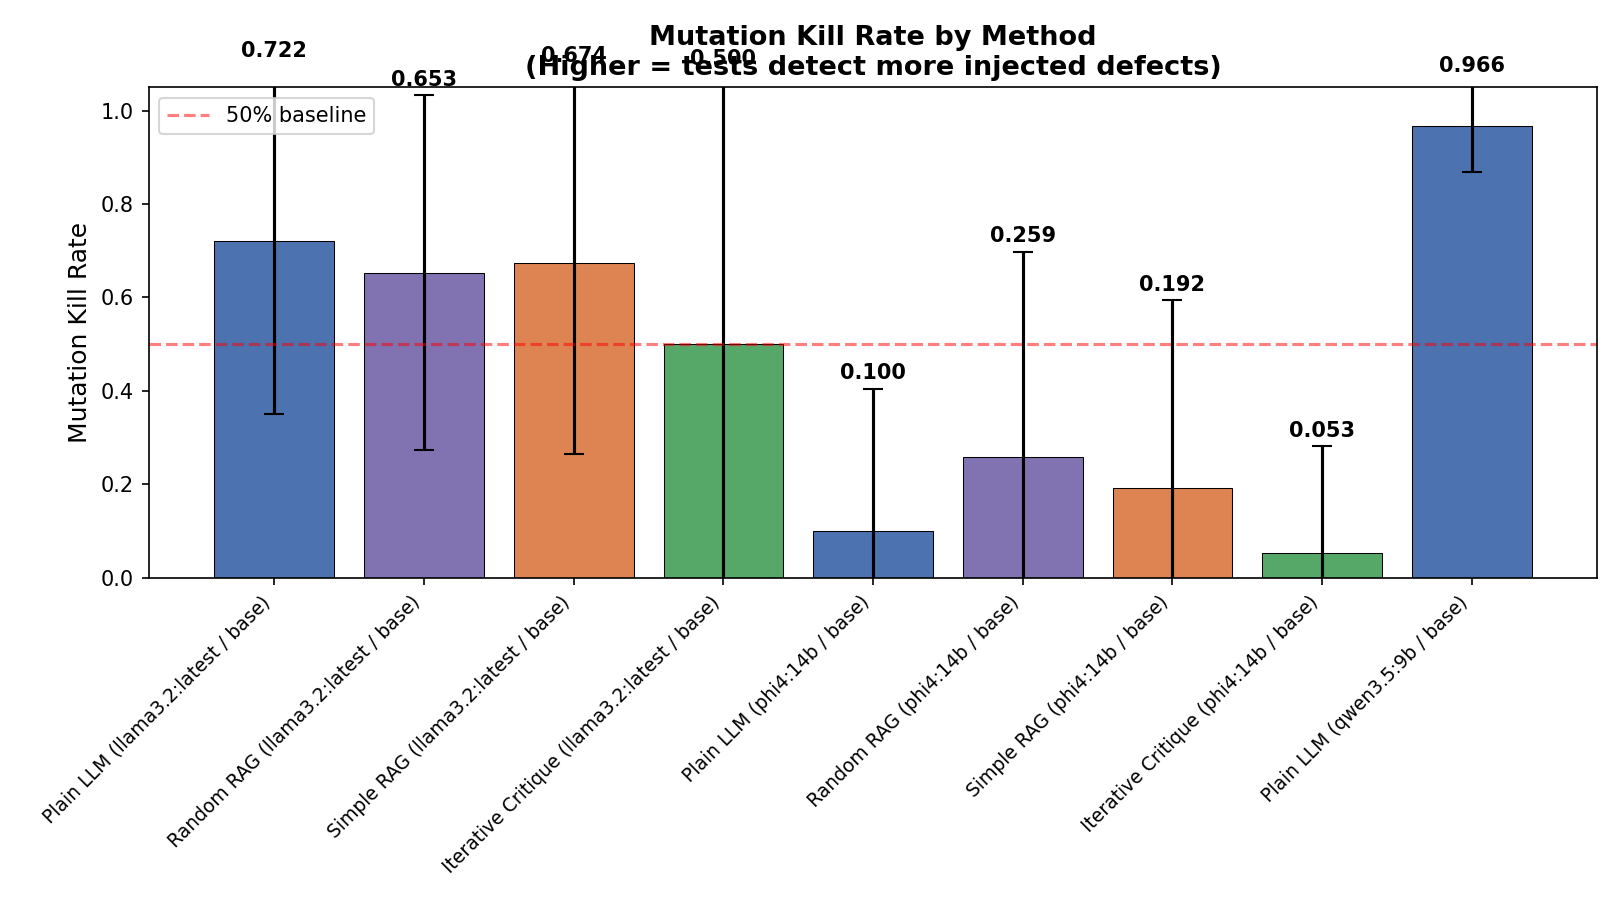

  mutation_kill_rate_by_operator.png → Drive


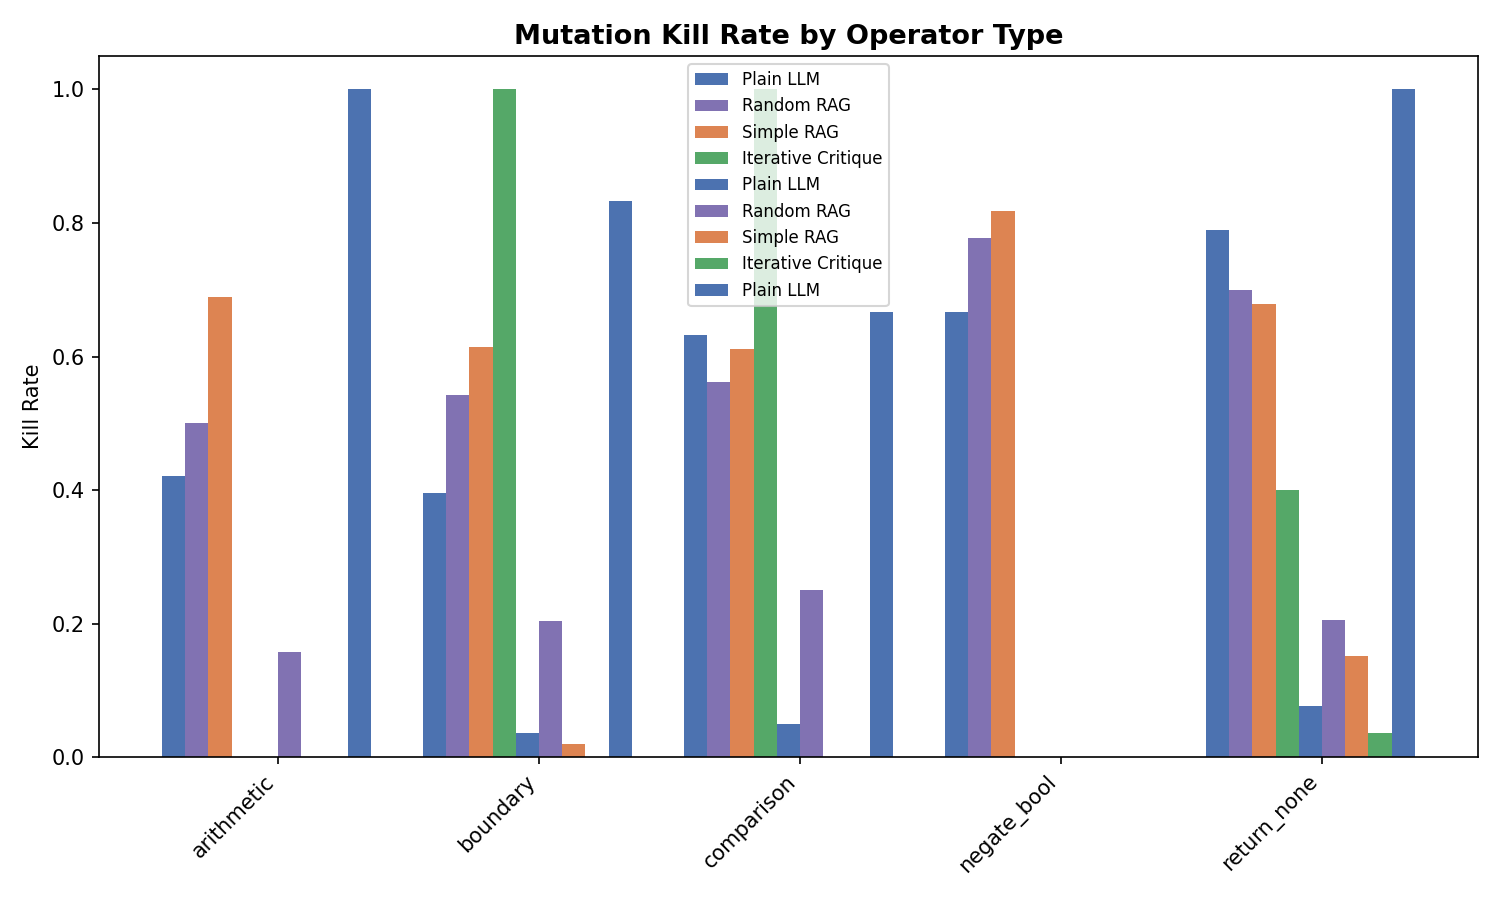

  mutation_report.txt → Drive

  MUTATION KILL RATE SUMMARY (all models)
            method           model reasoning  mean_kill_rate  std_kill_rate  n_samples_valid  total_killed  total_mutants
Iterative Critique llama3.2:latest      base        0.500000       0.577350                4             6             11
Iterative Critique        phi4:14b      base        0.052632       0.229416               19             1             99
         Plain LLM llama3.2:latest      base        0.721926       0.372199               29            87            160
         Plain LLM        phi4:14b      base        0.100000       0.305129               30             6            163
         Plain LLM      qwen3.5:9b      base        0.965909       0.096424                8            32             36
        Random RAG llama3.2:latest      base        0.652683       0.380034               22            79            135
        Random RAG        phi4:14b      base        0.259259       0.4389

In [ ]:
import os, shutil, subprocess, threading
import pandas as pd
from IPython.display import Image, display

# ---- Knobs ----
MUTATION_SAMPLES = 30
MUTATION_FRESH   = False              # ← False to resume; True to wipe and start over
MUTATION_MODELS  = ['qwen3.5:9b', 'qwen3-coder:30b']
SYNC_INTERVAL_SECS = 300              # Drive sync every 5 min while a model is running

os.chdir(REPO_DIR)
DRIVE_CKPT = os.path.join(DRIVE_DIR, 'checkpoints_mutation')

# ---- Optional fresh start ----
if MUTATION_FRESH:
    for path in ['.checkpoints_mutation', 'plots_mutation', 'results_mutation.tsv']:
        if os.path.isdir(path):
            shutil.rmtree(path, ignore_errors=True)
        elif os.path.isfile(path):
            os.remove(path)
    print('FRESH: cleared local mutation checkpoints, plots, TSV')
else:
    # Restore prior progress from Drive
    drive_tsv = os.path.join(DRIVE_DIR, 'results', 'results_mutation.tsv')
    if os.path.exists(drive_tsv):
        shutil.copy(drive_tsv, 'results_mutation.tsv')
        print('Restored results_mutation.tsv from Drive')
    if os.path.isdir(DRIVE_CKPT):
        os.makedirs('.checkpoints_mutation', exist_ok=True)
        n = 0
        for f in os.listdir(DRIVE_CKPT):
            shutil.copy(os.path.join(DRIVE_CKPT, f),
                        os.path.join('.checkpoints_mutation', f))
            n += 1
        print(f'Restored {n} mutation checkpoint files from Drive')

# ---- Skip models already complete in the TSV ----
def model_done(model_name):
    if not os.path.exists('results_mutation.tsv'):
        return False
    try:
        df = pd.read_csv('results_mutation.tsv', sep='\t')
    except Exception:
        return False
    if 'model' not in df.columns:
        return False
    return len(df[df['model'] == model_name]) >= 4   # 4 methods finished

# ---- Background syncer: copy local mutation checkpoints to Drive every N seconds ----
def _sync_checkpoints_once():
    if not os.path.isdir('.checkpoints_mutation'):
        return 0
    os.makedirs(DRIVE_CKPT, exist_ok=True)
    n = 0
    for f in os.listdir(DRIVE_CKPT):
        try:
            shutil.copy(os.path.join(DRIVE_CKPT, f),
                        os.path.join('.checkpoints_mutation', f))
            n += 1
        except Exception:
            pass
    return n

def _sync_loop(stop_event):
    while not stop_event.is_set():
        if stop_event.wait(SYNC_INTERVAL_SECS):
            break
        n = _sync_checkpoints_once()
        if n:
            print(f'  [sync] {n} checkpoint files → Drive')

# ---- Run mutation testing per model ----
for m in MUTATION_MODELS:
    if model_done(m):
        print(f'\nSKIP {m} — 4 method rows already in results_mutation.tsv')
        continue

    print(f'\n{"="*70}\n  MUTATION RUN — model = {m}\n{"="*70}')

    stop_event = threading.Event()
    syncer = threading.Thread(target=_sync_loop, args=(stop_event,), daemon=True)
    syncer.start()

    # Prepare a log file for this model's mutation run
    safe_model = m.replace(':', '-').replace('/', '-')
    log_filename = f'mutation_testing_{safe_model}.log'
    log_filepath_local = os.path.join(REPO_DIR, log_filename)

    print(f'  Logging output of mutation_testing.py to {log_filename}')

    with open(log_filepath_local, 'w') as log_file:
        try:
            rc = subprocess.run(
                ['python', 'mutation_testing.py',
                 '--regenerate',
                 '--max-samples', str(MUTATION_SAMPLES),
                 '--model', m],
                check=False,
                stdout=log_file,
                stderr=subprocess.STDOUT # Redirect stderr to stdout to capture all output
            ).returncode
        finally:
            stop_event.set()
            syncer.join(timeout=10)

    if rc != 0:
        print(f'  WARNING: mutation_testing.py exited with code {rc} for {m}. Check {log_filename} for details.')
    else:
        print(f'  Mutation testing for {m} completed successfully (exit code 0).')

    # Copy the log file to Drive
    save_to_both(log_filepath_local, log_filename, subdir='logs')

    # Final post-model sync (TSV + checkpoints)
    save_to_both('results_mutation.tsv', 'results_mutation.tsv')
    n = _sync_checkpoints_once()
    print(f'  Synced {n} checkpoint files to Drive after {m}')

# ---- Save final artifacts to Drive ----
for fname in ['kill_rate_by_method.png', 'kill_rate_by_operator.png']:
    src = os.path.join('plots_mutation', fname)
    save_to_both(src, f'mutation_{fname}', subdir='plots')
    if os.path.exists(src):
        display(Image(src))

save_to_both('plots_mutation/mutation_report.txt', 'mutation_report.txt')

# ---- Summary ----
if os.path.exists('results_mutation.tsv'):
    mdf = pd.read_csv('results_mutation.tsv', sep='\t')
    cols = [c for c in ['method', 'model', 'reasoning', 'mean_kill_rate',
                        'std_kill_rate', 'n_samples_valid',
                        'total_killed', 'total_mutants'] if c in mdf.columns]
    sort_cols = [c for c in ['method', 'model'] if c in mdf.columns]
    print('\n' + '='*70)
    print('  MUTATION KILL RATE SUMMARY (all models)')
    print('='*70)
    print(mdf[cols].sort_values(sort_cols).to_string(index=False))

    if 'model' in mdf.columns:
        print('\nPer-model mean kill rate:')
        print(mdf.groupby('model')['mean_kill_rate'].mean().round(4).to_string())
        print('\nPer-method mean kill rate (across models):')
        print(mdf.groupby('method')['mean_kill_rate'].mean().round(4).to_string())
else:
    print('No results_mutation.tsv produced.')